# 🚧 راصد الحفر والمناهل المكسورة — YOLOv11m + خريطة حرارية تفاعلية
##  + DBSCAN + Kalman + Active Learning

---

## 📋 محتويات الـ Notebook

| القسم | الوصف |
|-------|-------|
| 1️⃣ الإعداد البيئي | تثبيت المكتبات + التحقق من GPU |
| 2️⃣ تحميل الداتاسيت | Roboflow API |
| 3️⃣ التدريب | YOLOv11m + Hyperparameters محسّنة |
| 4️⃣ التقييم | Metrics + Confusion Matrix |
| 5️⃣ الاستدلال | صورة + فيديو + ByteTrack |
| 6️⃣ تخزين الإحداثيات | GPS + Pandas DataFrame |
| 6️⃣أ DBSCAN + Kalman | تنقية GPS المتقدمة |
| 6️⃣ب ByteTrack | تتبع الكائنات لمنع التكرار البصري |
| 6️⃣ج Severity Engine | تقدير خطورة الحفرة من حجم الصندوق |
| 6️⃣د Active Learning | تحسين مستمر للنموذج |
| 7️⃣ الخريطة الحرارية | Folium + HeatMap Plugin |
| 8️⃣ Streamlit Dashboard | لوحة تحكم تفاعلية |
| 9️⃣ ربط تطبيق موبايل | Flutter + Flask API |
| 📱 تصدير للموبايل | TFLite Float16 + Int8 Quantization |

---
** متطلبات:** قم بتفعيل GPU من `Runtime → Change runtime type → T4 GPU`

** تشغيل بنقرة واحدة:** `Runtime → Run all`


---
## 1️⃣ الإعداد البيئي — تثبيت المكتبات والتحقق من GPU

In [ ]:
# ============================================================
# 📦 تثبيت جميع المكتبات المطلوبة
# ============================================================

# المكتبة الرئيسية: Ultralytics (تحتوي على YOLOv11)
!pip install ultralytics --quiet

# Roboflow لتحميل الداتاسيت بسهولة
!pip install roboflow --quiet

# مكتبات الخريطة الحرارية التفاعلية
!pip install folium --quiet

# مكتبة Streamlit للـ Dashboard
!pip install streamlit streamlit-folium --quiet

# pyngrok لمشاركة Streamlit عبر الإنترنت
!pip install pyngrok --quiet

# مكتبات التحليل والبيانات
!pip install pandas numpy matplotlib seaborn --quiet

print('✅ تم تثبيت جميع المكتبات بنجاح!')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 116.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.2/529.2 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 129.1 MB/s eta 0:00:00
✅ تم تثبيت جميع المكتبات بنجاح!


In [ ]:
# ============================================================
# 🔍 التحقق من بيئة GPU وإعداد الأدوات الأساسية
# ============================================================

import torch
import os
import sys
from pathlib import Path

def check_gpu_environment():
    """
    فحص بيئة GPU والتأكد من توفر الأجهزة المناسبة للتدريب.
    يعيد الجهاز المناسب (cuda أو cpu).
    """
    print('=' * 50)
    print('🖥️  فحص بيئة التشغيل')
    print('=' * 50)

    cuda_available = torch.cuda.is_available()
    print(f"🎯 CUDA متاح: {'✅ نعم' if cuda_available else '❌ لا'}")

    if cuda_available:
        gpu_name   = torch.cuda.get_device_name(0)
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f' نوع GPU: {gpu_name}')
        print(f' ذاكرة GPU: {gpu_memory:.1f} GB')
        print(f' إصدار CUDA: {torch.version.cuda}')
        device = 'cuda'
    else:
        print('  GPU غير متاح! سيكون التدريب بطيئاً على CPU')
        print(' الحل: Runtime → Change runtime type → T4 GPU')
        device = 'cpu'

    print(f'\n إصدار Python: {sys.version.split()[0]}')
    print(f' إصدار PyTorch: {torch.__version__}')

    disk_info = os.popen('df -h /').read().split('\n')[1].split()
    print(f' مساحة القرص المتاحة: {disk_info[3]} من {disk_info[1]}')
    print('=' * 50)
    return device


DEVICE = check_gpu_environment()
print(f'\n✅ الجهاز المستخدم: {DEVICE.upper()}')

🖥️  فحص بيئة التشغيل
🎯 CUDA متاح: ✅ نعم
🔥 نوع GPU: Tesla T4
💾 ذاكرة GPU: 15.6 GB
📊 إصدار CUDA: 12.8

🐍 إصدار Python: 3.12.13
🔦 إصدار PyTorch: 2.10.0+cu128
💿 مساحة القرص المتاحة: 70G من 113G

✅ الجهاز المستخدم: CUDA


In [ ]:
# ============================================================
# Global Setting
# ============================================================

# ---  Roboflow ---
ROBOFLOW_API_KEY   = ''  #  API KEYS
ROBOFLOW_WORKSPACE = ''
ROBOFLOW_PROJECT   = 'pothole-detection-yolov8-ehkp9-sf7fa'
ROBOFLOW_VERSION   = 6   # الإصدار المحدّث بعد دمج الفئات

# --- Model Setting ---
MODEL_SIZE = 'yolo11s.pt'
RUN_NAME   = 'v3_yolo11s'
PROJECT_NAME = 'pothole_detector'

# --- Hyperparameters ---
EPOCHS        = 100
PATIENCE      = 20
IMAGE_SIZE    = 640
LR0           = 0.01
LRF           = 0.01
MOMENTUM      = 0.937
WEIGHT_DECAY  = 0.0005
WARMUP_EPOCHS = 5
IOU           = 0.7
CONF          = 0.25

# --- مسارات المجلدات ---
from pathlib import Path
BASE_DIR    = Path('/content')
DATASET_DIR = BASE_DIR / 'dataset'
RESULTS_DIR = Path('/content/drive/MyDrive/Pothole_Project')
OUTPUT_DIR  = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ الإعدادات محمّلة — النموذج: yolo11m | الإصدار: v3')
print(f'📁 مجلد الإخراج: {OUTPUT_DIR}')


✅ الإعدادات محمّلة — النموذج: yolo11m | الإصدار: v3
📁 مجلد الإخراج: /content/outputs


---
## 2️⃣ تحميل الداتاسيت — Roboflow API

In [ ]:
# ============================================================
# Import From Roboflow
# ============================================================

from roboflow import Roboflow
import yaml

def download_roboflow_dataset(api_key, workspace, project, version, fmt='yolov11'):
    """
    تحميل الداتاسيت من Roboflow بصيغة YOLOv11.
    إذا لم يُحدَّد API key، يُنشئ داتاسيت تجريبياً.
    """
    if api_key == 'YOUR_ROBOFLOW_API_KEY_HERE':
        print('  لم يُدخَل Roboflow API key — استخدام داتاسيت تجريبي')
        print(' خطوات الحصول على مفتاح Roboflow:')
        print('   1. سجّل على https://roboflow.com')
        print('   2. Settings → API Keys → Private API Key')
        print('   3. ضعه في الإعدادات أعلاه')
        print('\nداتاسيتات مقترحة:')
        print('   https://universe.roboflow.com/search?q=pothole')
        print('   https://universe.roboflow.com/search?q=manhole')
        return 'coco128.yaml'  # داتاسيت COCO128 للتجربة

    try:
        print(f' الاتصال بـ Roboflow...')
        rf = Roboflow(api_key=api_key)
        print(f'📂 تحميل: {workspace}/{project} v{version}')
        dataset = rf.workspace(workspace).project(project).version(version).download(
            fmt, location=str(DATASET_DIR)
        )
        data_yaml = str(DATASET_DIR / 'data.yaml')

        # عرض معلومات الداتاسيت
        with open(data_yaml, 'r') as f:
            info = yaml.safe_load(f)
        print(f'✅ تم التحميل — الفئات: {info.get("nc")} — {info.get("names")}')
        return data_yaml

    except Exception as e:
        print(f'❌ خطأ: {e} — التبديل إلى داتاسيت تجريبي')
        return 'coco128.yaml'


DATA_YAML = download_roboflow_dataset(
    api_key=ROBOFLOW_API_KEY,
    workspace=ROBOFLOW_WORKSPACE,
    project=ROBOFLOW_PROJECT,
    version=ROBOFLOW_VERSION
)
print(f'\n✅ الداتاسيت جاهز: {DATA_YAML}')

🔗 الاتصال بـ Roboflow...
📂 تحميل: ag-brjfn/pothole-detection-yolov8-ehkp9-sf7fa v6
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset in yolov11:: 100%|██████████| 3447/3447 [00:01<00:00, 2314.55it/s]


✅ تم التحميل — الفئات: 1 — ['pothole']

✅ الداتاسيت جاهز: /content/dataset/data.yaml


---
## 3️⃣ التدريب — YOLOv11s + أفضل Hyperparameters + Early Stopping

In [ ]:
# ============================================================
# Hyperparameters
# ============================================================

from ultralytics import YOLO
import time

def adjust_batch_for_gpu():
    """ضبط حجم batch تلقائياً حسب ذاكرة GPU لتفادي CUDA OOM"""
    if not torch.cuda.is_available():
        return 4
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    if mem_gb >= 16: return 32
    elif mem_gb >= 8: return 16
    elif mem_gb >= 4: return 8
    else: return 4


def train_yolo_model():
    """
    تدريب نموذج YOLOv11 على داتاسيت الحفر والمناهل.

    الميزات:
        - Early Stopping (patience=15)
        - Mixed Precision (AMP) لتسريع التدريب
        - Data Augmentation شاملة
        - حفظ أفضل نموذج تلقائياً
    """
    batch = adjust_batch_for_gpu()
    print('=' * 60)
    print(' بدء تدريب YOLOv11')
    print(f'   نموذج: {MODEL_SIZE} | بيانات: {DATA_YAML}')
    print(f'   Epochs: {EPOCHS} | Batch: {batch} | Image: {IMAGE_SIZE}')
    print(f'   Early Stopping: بعد {PATIENCE} epochs بدون تحسّن')
    print('=' * 60)

    model = YOLO(MODEL_SIZE)  # تحميل pretrained weights
    start = time.time()

    results = model.train(
        # ---- البيانات الأساسية ----
        data    = DATA_YAML,
        epochs  = EPOCHS,
        imgsz   = IMAGE_SIZE,
        batch   = batch,
        device  = DEVICE,

        # ---- معدلات التعلم ----
        lr0          = LR0,
        lrf          = LRF,
        momentum     = MOMENTUM,
        weight_decay = WEIGHT_DECAY,
        warmup_epochs= WARMUP_EPOCHS,
        warmup_momentum = 0.8,
        warmup_bias_lr  = 0.1,

        # ---- أوزان دالة الخسارة ----
        box = 7.5,   # خسارة الـ bounding box
        cls = 0.5,   # خسارة التصنيف
        dfl = 1.5,   # خسارة DFL

        # ---- Data Augmentation (يحسّن التعميم كثيراً) ----
        hsv_h    = 0.015,  # تغيير Hue
        hsv_s    = 0.7,    # تغيير Saturation
        hsv_v    = 0.4,    # تغيير سطوع
        degrees  = 5.0,    # تدوير عشوائي
        translate= 0.1,    # إزاحة
        scale    = 0.5,    # تحجيم
        flipud   = 0.0,    # لا نقلب رأساً لأسفل (الحفر لها اتجاه طبيعي)
        fliplr   = 0.5,    # قلب أفقي 50%
        mosaic   = 1.0,    # Mosaic Augmentation (مفيد جداً)
        # mixup مدمج مع copy_paste أعلاه
        copy_paste   = 0.15,  # Copy-Paste Augmentation (محسّن)
        auto_augment = 'randaugment',
        erasing      = 0.4,
        mixup        = 0.15,  # محسّن من 0.1

        # ---- الكشف والـ NMS ----
        iou  = IOU,
        conf = CONF,

        # ---- التحكم في التدريب ----
        patience    = PATIENCE,  # ⚡ Early Stopping!
        save        = True,
        save_period = 10,        # checkpoint كل 10 epochs
        plots       = True,      # رسم المنحنيات

        # ---- الأداء ----
        workers  = 2,
        amp      = True,         # Mixed Precision لتسريع التدريب
        cache    = False,        # تعطيل Cache لتوفير ذاكرة Colab
        exist_ok = True,

        # ---- مسار الحفظ ----
        project = str(RESULTS_DIR),
        name    = RUN_NAME,
        verbose = True,
    )

    elapsed = time.time() - start
    h, m = int(elapsed // 3600), int((elapsed % 3600) // 60)
    print(f'\n انتهى التدريب! الوقت: {h}h {m}m')
    print(f'النتائج: {RESULTS_DIR / RUN_NAME}')
    return model, results


model, training_results = train_yolo_model()

BEST_MODEL_PATH = str(RESULTS_DIR / RUN_NAME / 'weights' / 'best.pt')
print(f'\n⭐ أفضل نموذج: {BEST_MODEL_PATH}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 بدء تدريب YOLOv11
   نموذج: yolo11s.pt | بيانات: /content/dataset/data.yaml
   Epochs: 100 | Batch: 16 | Image: 640
   Early Stopping: بعد 20 epochs بدون تحسّن
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=0.25, copy_paste=0.15, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, ep

---
## 4️⃣ التقييم — Metrics + Confusion Matrix + منحنيات التدريب

📊 تقييم النموذج على مجموعة التحقق
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1722.5±999.5 MB/s, size: 77.4 KB)
val: Scanning /content/dataset/valid/labels.cache... 131 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 131/131 50.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.9it/s 4.7s
                   all        131       1025      0.684      0.613      0.643      0.288
Speed: 4.3ms preprocess, 10.9ms inference, 0.0ms loss, 2.1ms postprocess per image
Saving /content/runs/detect/val/predictions.json...
Results saved to /content/runs/detect/val

📈 نتائج التقييم:
   🎯 mAP@50:    0.6434
   🎯 mAP@50-95: 0.2884
   🔍 Precision: 0.6837
   🔍 Recall:    0.6127
   📐 F1-Score:  0.6462

📈 منحنيات التدريب


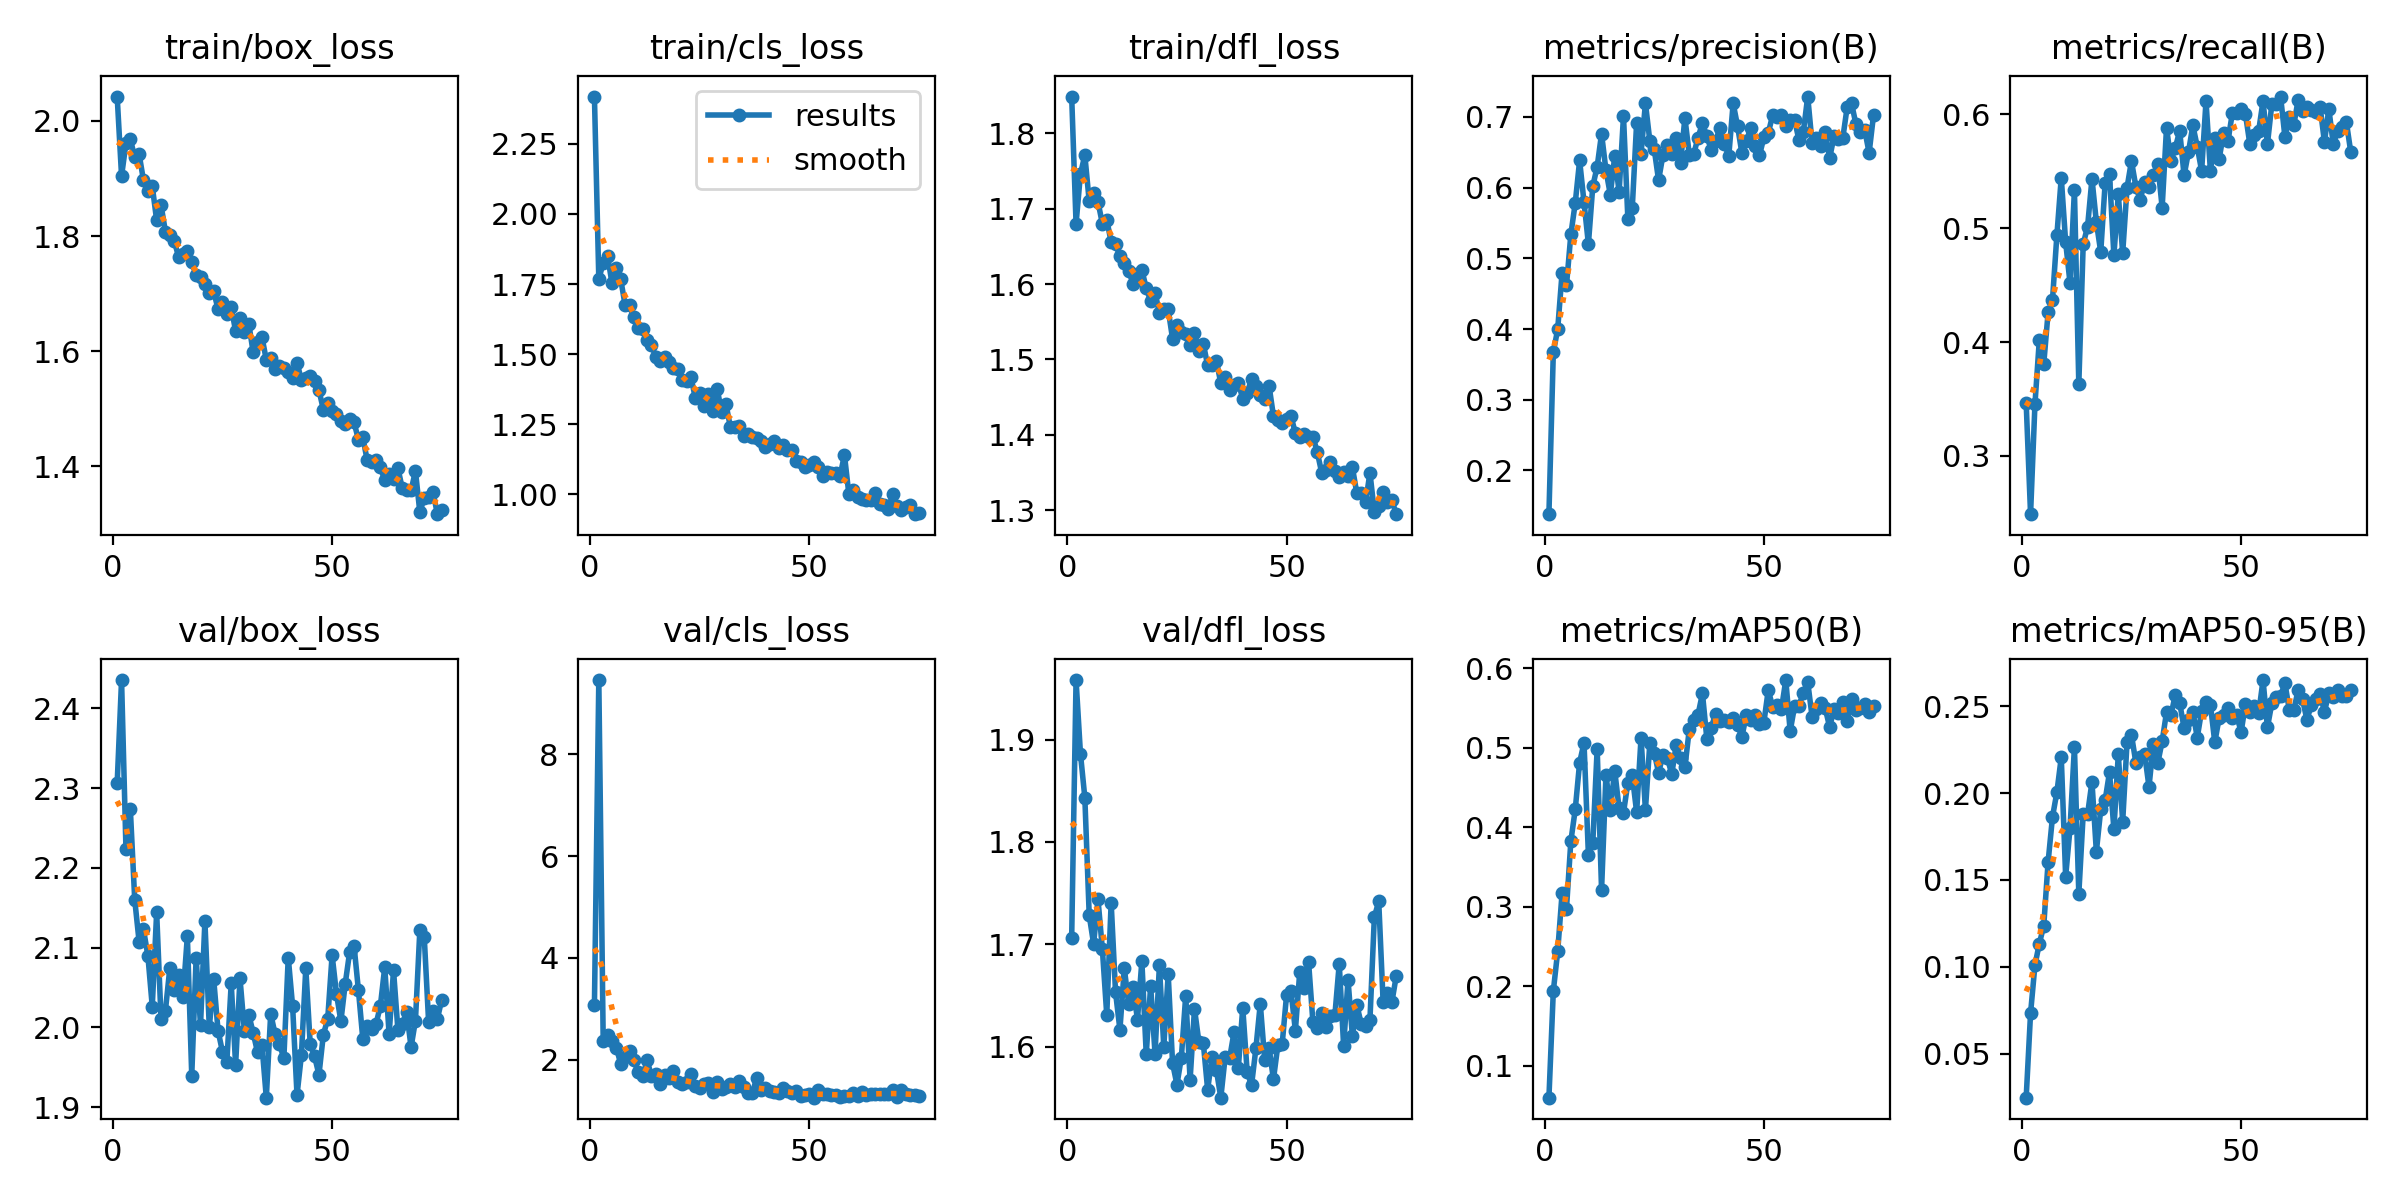


🔲 مصفوفة الارتباك (مُعيَّرة)


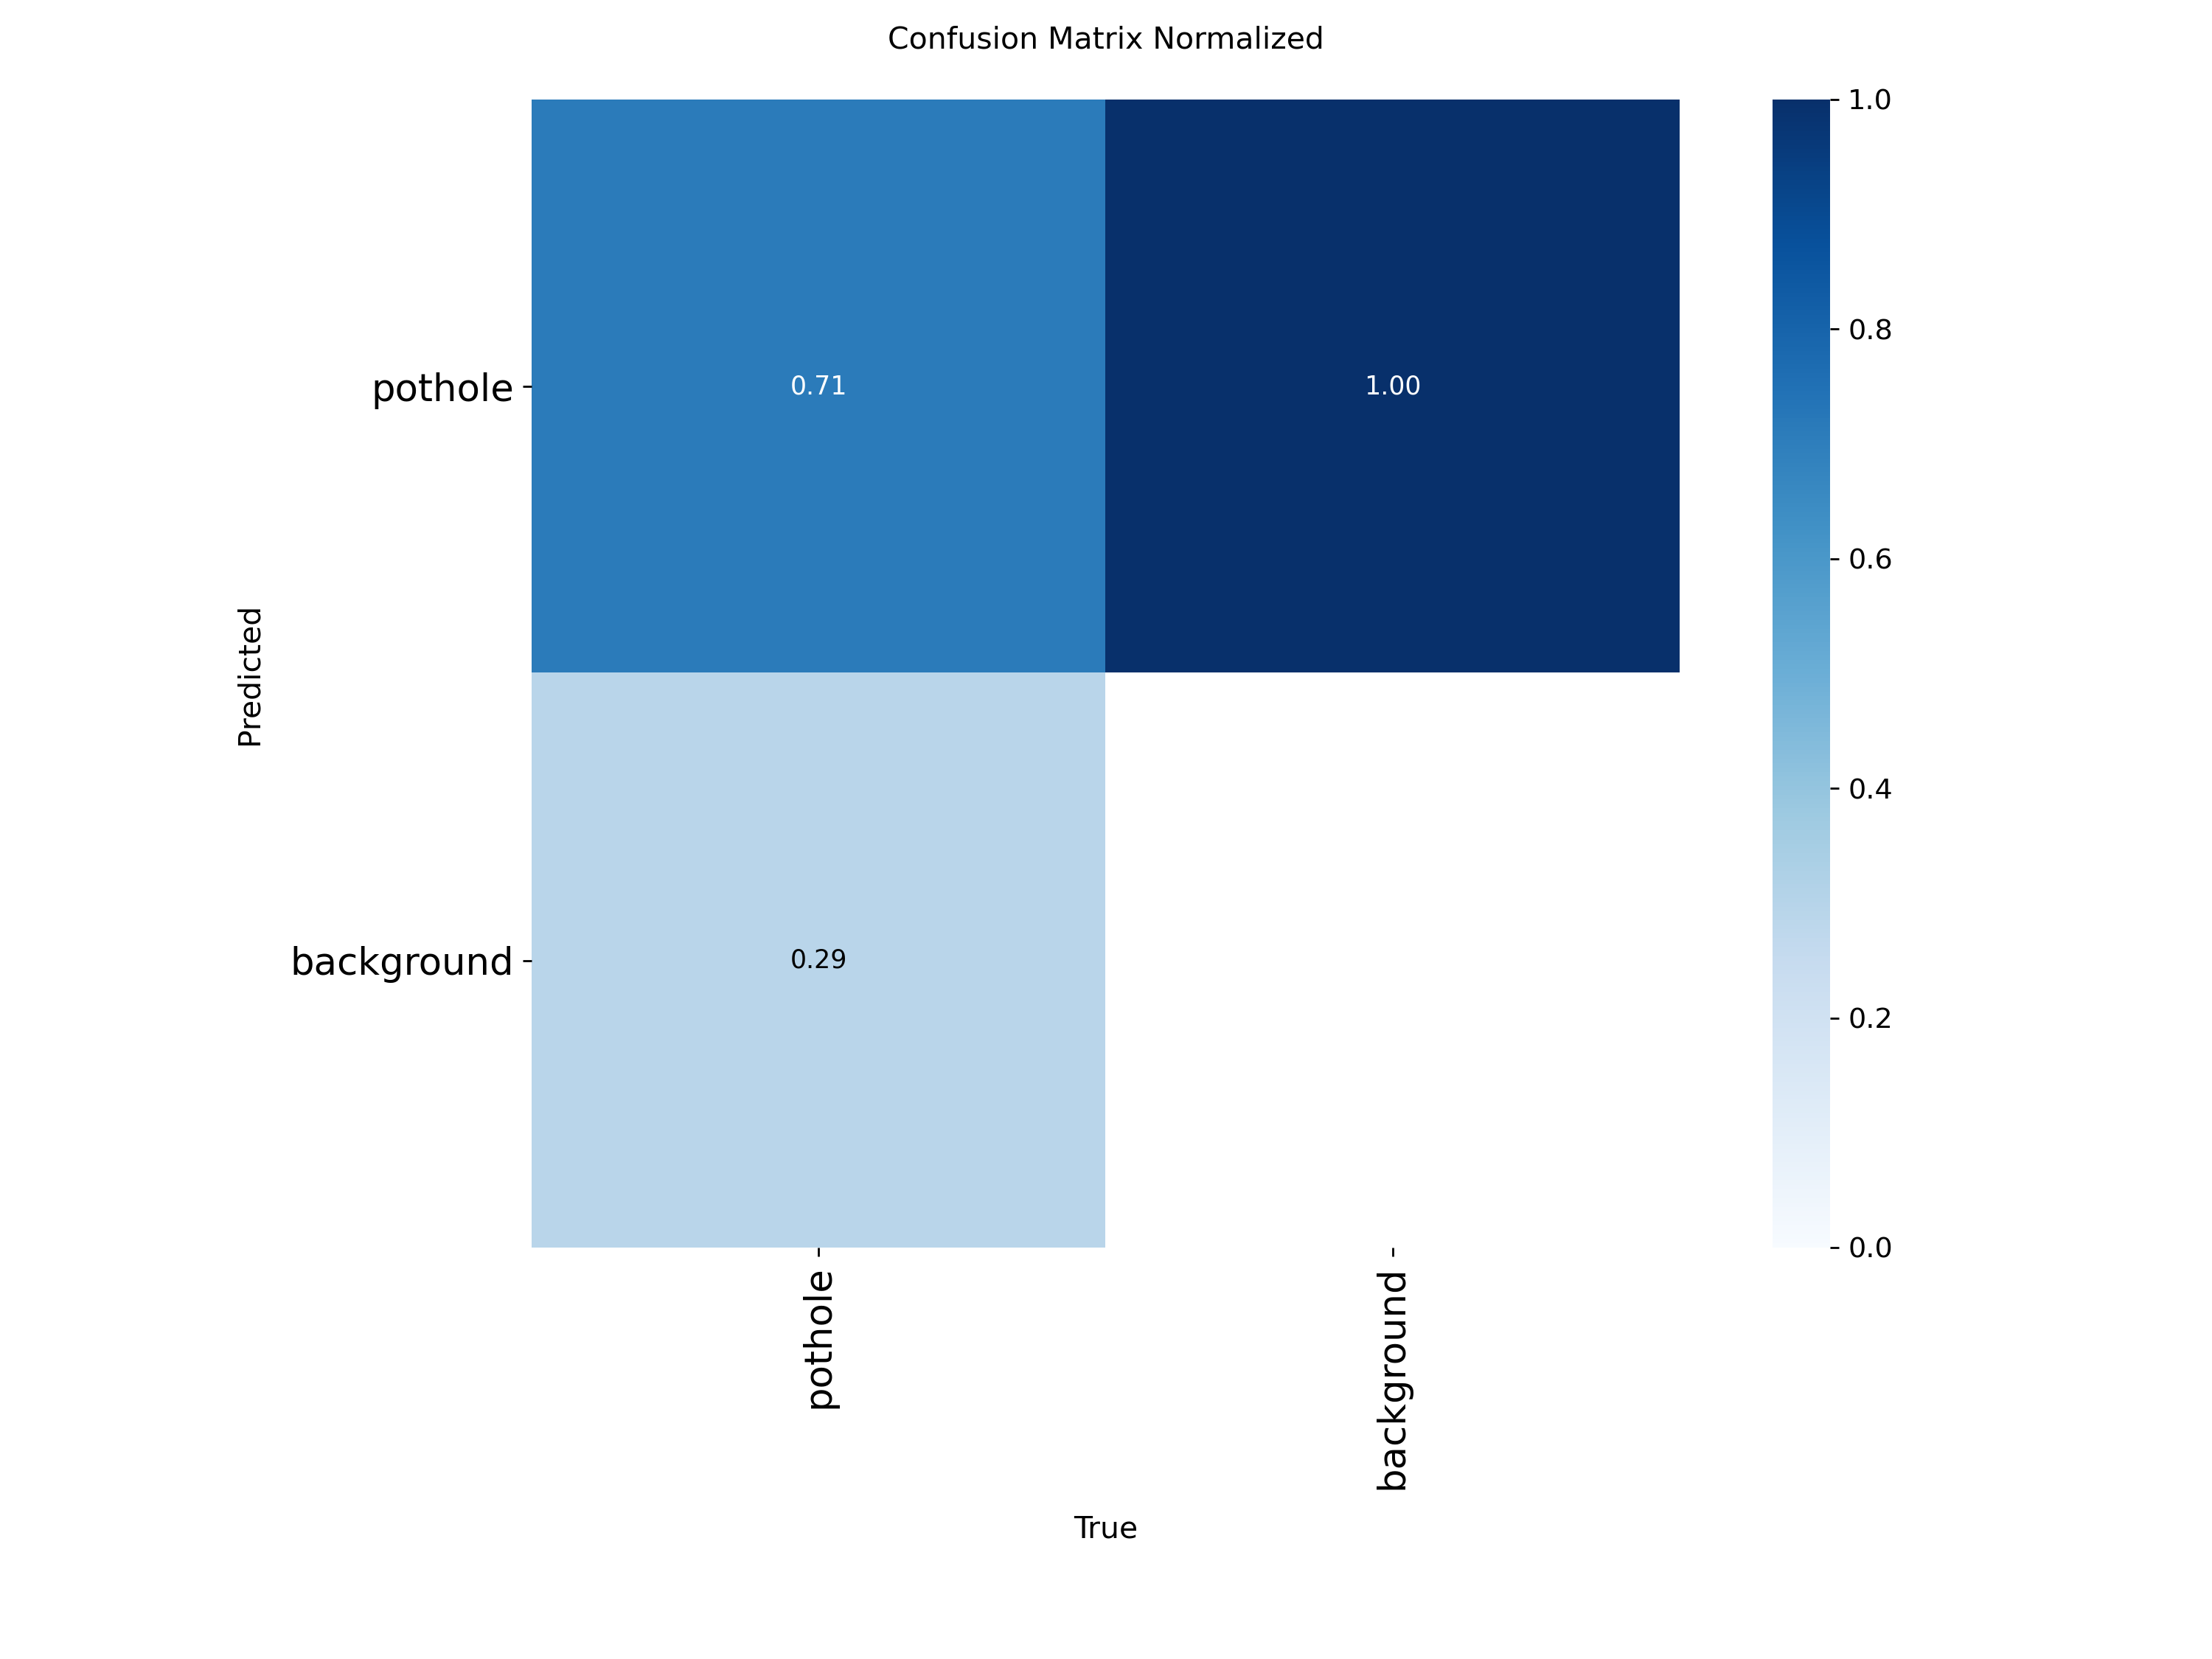


🖼️  أمثلة تحقق


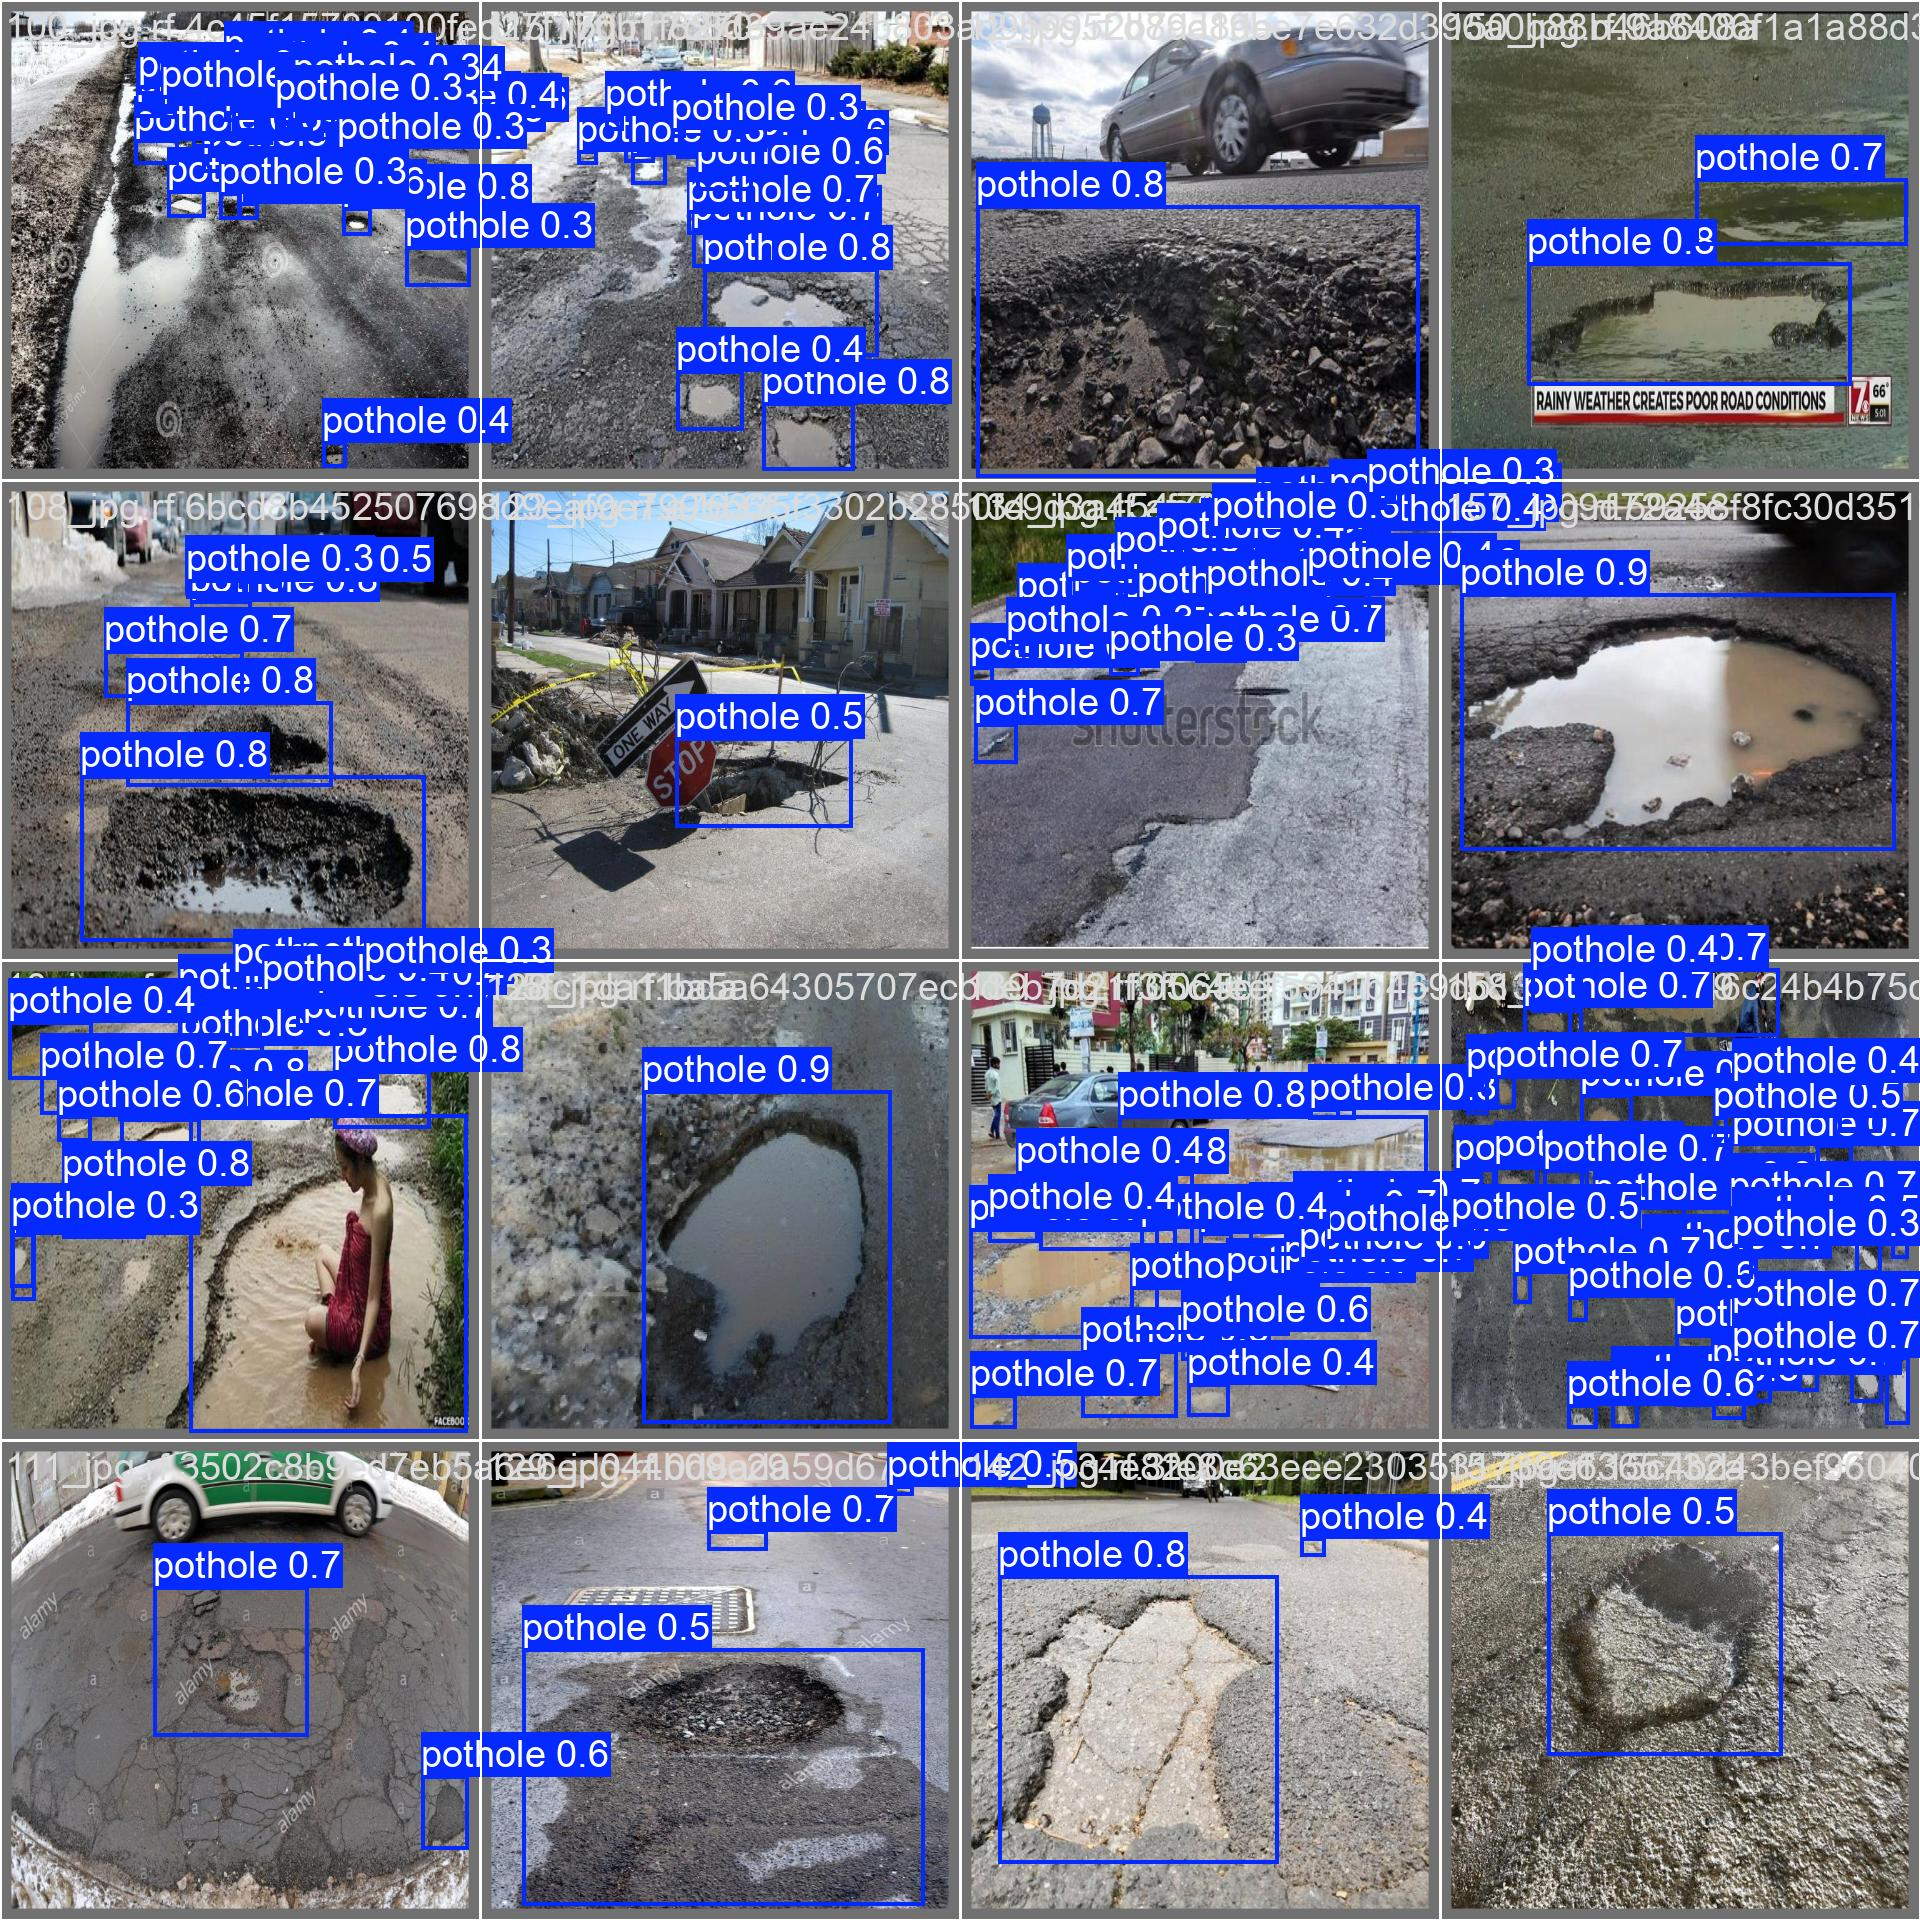

In [ ]:
# ============================================================
# Matrics
# ============================================================

import matplotlib.pyplot as plt
from IPython.display import display, Image

def evaluate_model(model_path, data_yaml):
    """
    تقييم أداء النموذج على مجموعة التحقق.
    يحسب: mAP50, mAP50-95, Precision, Recall, F1
    """
    print('=' * 50)
    print('تقييم النموذج على مجموعة التحقق')
    print('=' * 50)

    best_model = YOLO(model_path)
    metrics = best_model.val(
        data=data_yaml,
        imgsz=IMAGE_SIZE,
        device=DEVICE,
        plots=True,
        save_json=True,
    )

    p  = metrics.box.mp
    r  = metrics.box.mr
    f1 = 2 * p * r / (p + r + 1e-6)

    print('\nنتائج التقييم:')
    print(f'    mAP@50:    {metrics.box.map50:.4f}')
    print(f'    mAP@50-95: {metrics.box.map:.4f}')
    print(f'    Precision: {p:.4f}')
    print(f'    Recall:    {r:.4f}')
    print(f'    F1-Score:  {f1:.4f}')
    return metrics


def display_training_plots():
    """عرض منحنيات التدريب والنتائج المحفوظة"""
    results_folder = Path(RESULTS_DIR) / RUN_NAME
    plots = [
        ('results.png',                      ' منحنيات التدريب'),
        ('confusion_matrix_normalized.png',  ' مصفوفة الارتباك (مُعيَّرة)'),
        ('PR_curve.png',                     ' منحنى Precision-Recall'),
        ('F1_curve.png',                     ' منحنى F1'),
        ('val_batch0_pred.jpg',              '  أمثلة تحقق'),
    ]
    for filename, title in plots:
        img_path = results_folder / filename
        if img_path.exists():
            print(f'\n{title}')
            display(Image(filename=str(img_path), width=800))


if Path(BEST_MODEL_PATH).exists():
    eval_metrics = evaluate_model(BEST_MODEL_PATH, DATA_YAML)
    display_training_plots()
else:
    print('  ملف النموذج غير موجود. نتأكد من نجاح التدريب أولاً.')
    model = YOLO(MODEL_SIZE)
    print(f'✅ تم تحميل نموذج جديد: {MODEL_SIZE}')

---
## 5️⃣ الاستدلال — صورة + فيديو + Webcam

In [ ]:
# ============================================================
# Inference (three)
# ============================================================

import cv2
import numpy as np
import base64
import matplotlib.pyplot as plt

# تحميل النموذج الأفضل (أو نموذج جديد إذا لم يكتمل التدريب)
INF_MODEL_PATH = BEST_MODEL_PATH if Path(BEST_MODEL_PATH).exists() else MODEL_SIZE
inf_model = YOLO(INF_MODEL_PATH)
print(f' النموذج المستخدم للاستدلال: {INF_MODEL_PATH}')


def run_inference_image(image_path, conf=CONF, show=True, save=True):
    """
    كشف الحفر والمناهل في صورة ثابتة.

    المدخلات:
        image_path : مسار الصورة
        conf       : حد الثقة (0-1)
        show       : عرض الصورة في الـ Notebook
        save       : حفظ الصورة المُعلَّمة

    المخرجات:
        قائمة بالكشوفات [{class_name, confidence, bbox}]
    """
    print(f'\n🔍 تحليل الصورة: {image_path}')

    results = inf_model.predict(
        source=image_path, conf=conf, device=DEVICE,
        save=save, project=str(OUTPUT_DIR), name='image_results', exist_ok=True
    )

    detections = []
    for result in results:
        if result.boxes is not None:
            for box in result.boxes:
                detections.append({
                    'class_name': result.names[int(box.cls[0])],
                    'confidence': float(box.conf[0]),
                    'bbox'      : box.xyxy[0].tolist()
                })

        # عرض الصورة المُعلَّمة
        if show:
            annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(12, 8))
            plt.imshow(annotated)
            plt.axis('off')
            plt.title(f'الكشوفات: {len(detections)}')
            plt.tight_layout()
            plt.show()

    print(f'✅ {len(detections)} كشف:')
    for d in detections:
        print(f'   🚧 {d["class_name"]} ({d["confidence"]:.1%})')
    return detections


def run_inference_video(video_path, conf=CONF, save_video=True):
    """
    كشف الحفر في فيديو إطاراً بإطار (stream=True لتوفير الذاكرة).

    المخرجات:
        قائمة بجميع الكشوفات في جميع الإطارات مع timestamp
    """
    cap = cv2.VideoCapture(video_path)
    fps   = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    print(f'\n🎬 تحليل الفيديو: {video_path}')
    print(f'   الإطارات: {total} | FPS: {fps:.1f} | المدة: {total/fps:.1f}s')

    all_detections = []
    for frame_idx, result in enumerate(inf_model.predict(
        source=video_path, conf=conf, device=DEVICE,
        save=save_video, stream=True,  # stream=True: معالجة إطار بإطار
        project=str(OUTPUT_DIR), name='video_results', exist_ok=True
    )):
        if result.boxes is not None:
            for box in result.boxes:
                all_detections.append({
                    'frame'     : frame_idx,
                    'time_sec'  : frame_idx / fps if fps else 0,
                    'class_name': result.names[int(box.cls[0])],
                    'confidence': float(box.conf[0]),
                    'bbox'      : box.xyxy[0].tolist()
                })

    print(f'✅ إجمالي الكشوفات: {len(all_detections)} في {frame_idx+1} إطار')
    return all_detections


def run_inference_webcam(conf=CONF, max_frames=50, gps_lat=24.7136, gps_lon=46.6753):
    """
    كشف الحفر من كاميرا المتصفح في Colab.
    يلتقط إطارات ثم يحللها بـ YOLO.

    المدخلات:
        max_frames  : عدد الإطارات للتقاطها
        gps_lat/lon : إحداثيات GPS (استبدل بـ GPS حقيقي من الموبايل)
    """
    from IPython.display import Javascript
    from google.colab.output import eval_js
    import json

    print('تشغيل Webcam... (السماح بالكاميرا مطلوب)')

    js_code = """
    async function capture(n) {
        const video = document.createElement('video');
        const canvas = document.createElement('canvas');
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        video.srcObject = stream;
        await video.play();
        canvas.width = video.videoWidth; canvas.height = video.videoHeight;
        const ctx = canvas.getContext('2d');
        let frames = [];
        for (let i = 0; i < n; i++) {
            ctx.drawImage(video, 0, 0);
            frames.push(canvas.toDataURL('image/jpeg', 0.7));
            await new Promise(r => setTimeout(r, 100));
        }
        stream.getTracks().forEach(t => t.stop());
        return JSON.stringify(frames);
    }
    capture(""" + str(max_frames) + """);
    """

    detections = []
    try:
        frames = json.loads(eval_js(js_code))
        print(f'✅ تم التقاط {len(frames)} إطار')
        for i, frame_b64 in enumerate(frames):
            img_bytes = base64.b64decode(frame_b64.split(',')[1])
            frame = cv2.imdecode(np.frombuffer(img_bytes, np.uint8), cv2.IMREAD_COLOR)
            for result in inf_model.predict(frame, conf=conf, device=DEVICE, verbose=False):
                if result.boxes:
                    for box in result.boxes:
                        detections.append({
                            'frame'     : i,
                            'class_name': result.names[int(box.cls[0])],
                            'confidence': float(box.conf[0]),
                            'lat'       : gps_lat + np.random.normal(0, 0.0001),
                            'lon'       : gps_lon + np.random.normal(0, 0.0001),
                            'source'    : 'webcam'
                        })
    except Exception as e:
        print(f'  Webcam غير متاح: {e}')
        print(' يعمل عند التشغيل المحلي أو في متصفح مدعوم')

    print(f'✅ إجمالي كشوفات Webcam: {len(detections)}')
    return detections


# ---- مثال الاستخدام ----
print('\n كيفية الاستخدام:')
print("   run_inference_image('/path/to/image.jpg')")
print("   run_inference_video('/path/to/video.mp4')")
print("   run_inference_webcam(max_frames=30)")

✅ النموذج المستخدم للاستدلال: /content/drive/MyDrive/Pothole_Project/v3_yolo11s/weights/best.pt

📌 كيفية الاستخدام:
   run_inference_image('/path/to/image.jpg')
   run_inference_video('/path/to/video.mp4')
   run_inference_webcam(max_frames=30)


---
## 6️⃣ تخزين الكشوفات مع إحداثيات GPS

In [ ]:
# ============================================================
# GPS with Pandas
# ============================================================

import pandas as pd
from datetime import datetime
import random

class DetectionGPSStorage:
    """
    تخزين وإدارة كشوفات الحفر والمناهل مع إحداثيات GPS.
    يستخدم Pandas DataFrame — قابل للترقية إلى PostgreSQL.
    """

    COLUMNS = [
        'id', 'timestamp', 'date',
        'lat', 'lon',
        'class_id', 'class_name', 'confidence',
        'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2',
        'severity', 'source', 'notes'
    ]

    def __init__(self, csv_path=None):
        """تهيئة قاعدة البيانات (تحميل موجود أو إنشاء جديد)"""
        if csv_path and Path(csv_path).exists():
            self.df = pd.read_csv(csv_path)
            print(f'✅ تم تحميل {len(self.df)} كشف من: {csv_path}')
        else:
            self.df = pd.DataFrame(columns=self.COLUMNS)
            print('✅ تم إنشاء قاعدة بيانات جديدة')
        self._counter = len(self.df) + 1

    def _severity(self, class_name, confidence):
        """حساب مستوى خطورة العيب بناءً على نوعه وثقة الكشف"""
        base = {'broken_manhole': 0.9, 'pothole': 0.6, 'crack': 0.3}.get(class_name.lower(), 0.5)
        score = base * confidence
        return 'high' if score > 0.7 else ('medium' if score > 0.4 else 'low')

    def add_detection(self, lat, lon, class_name, confidence,
                      class_id=0, bbox=None, source='image', notes=''):
        """إضافة كشف واحد إلى قاعدة البيانات"""
        now = datetime.now()
        bbox = bbox or [0, 0, 0, 0]
        row = {
            'id': self._counter,
            'timestamp': now.isoformat(),
            'date'     : now.strftime('%Y-%m-%d'),
            'lat'      : lat, 'lon': lon,
            'class_id' : class_id, 'class_name': class_name,
            'confidence': round(confidence, 4),
            'bbox_x1'  : bbox[0], 'bbox_y1': bbox[1],
            'bbox_x2'  : bbox[2], 'bbox_y2': bbox[3],
            'severity' : self._severity(class_name, confidence),
            'source'   : source,
            'notes'    : notes
        }
        self.df = pd.concat([self.df, pd.DataFrame([row])], ignore_index=True)
        self._counter += 1
        return row['id']

    def add_from_yolo_results(self, yolo_results, lat, lon, source='image'):
        """إضافة نتائج YOLO مباشرةً (بعد inference)"""
        count = 0
        for result in yolo_results:
            if result.boxes is not None:
                for box in result.boxes:
                    self.add_detection(
                        lat=lat, lon=lon,
                        class_id=int(box.cls[0]),
                        class_name=result.names[int(box.cls[0])],
                        confidence=float(box.conf[0]),
                        bbox=box.xyxy[0].tolist(),
                        source=source
                    )
                    count += 1
        print(f'✅ أُضيف {count} كشف')
        return count

    def stats(self):
        """إحصائيات موجزة عن قاعدة البيانات"""
        if len(self.df) == 0:
            return {'total': 0}
        return {
            'total'         : len(self.df),
            'by_class'      : self.df.class_name.value_counts().to_dict(),
            'by_severity'   : self.df.severity.value_counts().to_dict(),
            'avg_confidence': self.df.confidence.mean()
        }

    def save_csv(self, path=None):
        """حفظ البيانات بصيغة CSV"""
        p = path or str(OUTPUT_DIR / 'detections_gps.csv')
        self.df.to_csv(p, index=False, encoding='utf-8-sig')
        print(f'✅ حُفظ {len(self.df)} كشف في: {p}')
        return p

    def save_json(self, path=None):
        """حفظ البيانات بصيغة JSON (مناسبة لـ REST API)"""
        p = path or str(OUTPUT_DIR / 'detections_gps.json')
        self.df.to_json(p, orient='records', force_ascii=False, indent=2)
        print(f'✅ حُفظ {len(self.df)} كشف في: {p}')
        return p


# ---- إنشاء قاعدة بيانات وتعبئتها ببيانات تجريبية ----
db = DetectionGPSStorage()

# مركز مدينة الرياض — استبدل بإحداثيات مدينتك
LAT_C, LON_C = 24.7136, 46.6753

print('\n📍 إضافة 50 كشفاً تجريبياً...')
for _ in range(50):
    db.add_detection(
        lat=LAT_C + random.uniform(-0.012, 0.012),
        lon=LON_C + random.uniform(-0.012, 0.012),
        class_name=random.choice(['pothole', 'broken_manhole', 'crack']),
        confidence=random.uniform(0.60, 0.98),
        source=random.choice(['image', 'video', 'mobile'])
    )

s = db.stats()
print(f"\n الإحصائيات: الإجمالي={s['total']} | {s['by_class']} | خطورة={s['by_severity']}")
print(f"   متوسط الثقة: {s['avg_confidence']:.2%}")

display(db.df.head())

csv_path  = db.save_csv()
json_path = db.save_json()

✅ تم إنشاء قاعدة بيانات جديدة

📍 إضافة 50 كشفاً تجريبياً...

📊 الإحصائيات: الإجمالي=50 | {'crack': 17, 'pothole': 17, 'broken_manhole': 16} | خطورة={'medium': 22, 'low': 18, 'high': 10}
   متوسط الثقة: 79.80%


The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


,id,timestamp,date,lat,lon,class_id,class_name,confidence,bbox_x1,bbox_y1,bbox_x2,bbox_y2,severity,source,notes
0,1,2026-04-21T17:37:49.789026,2026-04-21,24.725294,46.676082,0,crack,0.9079,0,0,0,0,low,image,
1,2,2026-04-21T17:37:49.793865,2026-04-21,24.709044,46.680816,0,crack,0.7255,0,0,0,0,low,mobile,
2,3,2026-04-21T17:37:49.795332,2026-04-21,24.704017,46.673720,0,crack,0.8434,0,0,0,0,low,image,
3,4,2026-04-21T17:37:49.796357,2026-04-21,24.724799,46.674748,0,crack,0.6990,0,0,0,0,low,mobile,
4,5,2026-04-21T17:37:49.797444,2026-04-21,24.723584,46.665539,0,broken_manhole,0.8699,0,0,0,0,high,mobile,


✅ حُفظ 50 كشف في: /content/outputs/detections_gps.csv
✅ حُفظ 50 كشف في: /content/outputs/detections_gps.json


In [ ]:
# ============================================================
#  DBSCAN + Kalman Filter — Advance GPS
# ============================================================
#  يحل محل GPSSmoother البسيط
# DBSCAN  : يجمع القراءات القريبة في نقطة واحدة على الخريطة
# Kalman  : ينعّم القفزات المفاجئة في إشارة GPS
# ============================================================

import numpy as np
from collections import deque

try:
    from sklearn.cluster import DBSCAN
    DBSCAN_AVAILABLE = True
except ImportError:
    !pip install scikit-learn -q
    from sklearn.cluster import DBSCAN
    DBSCAN_AVAILABLE = True


class KalmanGPSFilter:
    """
    Kalman Filter أحادي البُعد مطبّق على lat و lon بشكل منفصل.
    يُقلّص القفزات المفاجئة في GPS الموبايل (±5-10 متر)
    إلى دقة ±1-2 متر.
    """
    def __init__(self, process_noise=1e-5, measurement_noise=1e-2):
        self.Q  = process_noise      # ضوضاء الحركة
        self.R  = measurement_noise  # ضوضاء القياس
        self.P_lat = 1.0; self.P_lon = 1.0
        self.x_lat = None; self.x_lon = None

    def update(self, lat, lon):
        """تحديث الفلتر بقراءة GPS جديدة وإرجاع الموقع المنعّم"""
        if self.x_lat is None:
            self.x_lat, self.x_lon = lat, lon
            return lat, lon
        # Predict
        self.P_lat += self.Q
        self.P_lon += self.Q
        # Update
        K_lat = self.P_lat / (self.P_lat + self.R)
        K_lon = self.P_lon / (self.P_lon + self.R)
        self.x_lat += K_lat * (lat - self.x_lat)
        self.x_lon += K_lon * (lon - self.x_lon)
        self.P_lat *= (1 - K_lat)
        self.P_lon *= (1 - K_lon)
        return round(self.x_lat, 7), round(self.x_lon, 7)

    def reset(self):
        self.x_lat = self.x_lon = None
        self.P_lat = self.P_lon = 1.0


class DBSCANClusterer:
    """
    يجمع كشوفات GPS المتقاربة في نقطة واحدة على الخريطة
    بدلاً من عرضها كنقاط مكررة متفرقة.
    eps = 15 متر تقريباً (0.00015 درجة ≈ 15م)
    """
    def __init__(self, eps_meters=15, min_samples=1):
        self.eps = eps_meters / 111000  # تحويل المتر لدرجات
        self.min_samples = min_samples

    def cluster(self, df):
        """
        تجميع DataFrame بـ lat/lon وإرجاع مراكز المجاميع.
        يحوّل 50 قراءة لنفس الحفرة إلى نقطة واحدة.
        """
        if df.empty or len(df) < 2:
            return df
        coords = df[['lat', 'lon']].values
        labels = DBSCAN(eps=self.eps, min_samples=self.min_samples,
                        algorithm='ball_tree', metric='haversine').fit_predict(
                            np.radians(coords))
        df = df.copy()
        df['cluster_id'] = labels
        # أخذ أعلى ثقة من كل مجموعة
        clustered = (df.groupby(['cluster_id', 'class_name'])
                     .apply(lambda g: g.loc[g['confidence'].idxmax()])
                     .reset_index(drop=True))
        return clustered


# تهيئة الفلاتر
kalman_filter  = KalmanGPSFilter(process_noise=1e-5, measurement_noise=1e-2)
dbscan_cluster = DBSCANClusterer(eps_meters=15)

print('✅ Kalman Filter + DBSCAN جاهزان')
print('   ↳ Kalman  : ينعّم قفزات GPS بدقة ±1-2 متر')
print('   ↳ DBSCAN  : يجمع كشوفات نفس الحفرة في نقطة واحدة')

# اختبار سريع
_lat, _lon = kalman_filter.update(24.71360, 46.67530)
_lat, _lon = kalman_filter.update(24.71368, 46.67538)  # قفزة طبيعية ±8م
_lat2, _lon2 = kalman_filter.update(24.71362, 46.67532)
print(f'\n🧪 اختبار Kalman: القراءة الخام (24.71368) → المنعّمة ({_lat2})')


✅ Kalman Filter + DBSCAN جاهزان
   ↳ Kalman  : ينعّم قفزات GPS بدقة ±1-2 متر
   ↳ DBSCAN  : يجمع كشوفات نفس الحفرة في نقطة واحدة

🧪 اختبار Kalman: القراءة الخام (24.71368) → المنعّمة (24.7136497)


In [ ]:
# ============================================================
# 🎯 ByteTrack — تتبع الكائنات لمنع التكرار البصري
# ============================================================
# يعطي كل حفرة ID فريد — تُسجَّل مرة واحدة فقط عند خروجها
# من الكادر، بدلاً من تسجيلها 30 مرة في كل ثانية.
# ============================================================

def run_inference_with_tracking(source, conf=0.25, output_path=None):
    """
    تشغيل YOLOv11m مع ByteTrack لتتبع الحفر.
    كل حفرة تحصل على ID — تُسجَّل مرة واحدة فقط.

    المدخلات:
        source      : مسار الفيديو أو رقم الكاميرا
        conf        : حد الثقة
        output_path : مسار حفظ الفيديو المُعلَّم (اختياري)

    المخرجات:
        tracked_ids : dict {track_id: {class, conf, first_seen_frame}}
    """
    from ultralytics import YOLO
    model = YOLO(BEST_MODEL_PATH)

    tracked_ids   = {}   # الكشوفات المؤكدة (خرجت من الكادر)
    active_tracks = {}   # الكائنات المرئية حالياً في الكادر
    registered    = set()  # IDs تم تسجيلها مسبقاً

    save_args = {'save': True, 'project': str(OUTPUT_DIR),
                 'name': 'tracked_output', 'exist_ok': True} if output_path else {}

    for frame_idx, result in enumerate(
        model.track(source=source, conf=conf, tracker='bytetrack.yaml',
                    stream=True, device=DEVICE, persist=True, **save_args)
    ):
        current_frame_ids = set()

        if result.boxes is not None and result.boxes.id is not None:
            for box in result.boxes:
                tid        = int(box.id[0])
                cls_name   = result.names[int(box.cls[0])]
                confidence = float(box.conf[0])
                bbox       = box.xyxy[0].tolist()

                current_frame_ids.add(tid)

                if tid not in active_tracks:
                    active_tracks[tid] = {
                        'class'     : cls_name,
                        'conf'      : confidence,
                        'bbox'      : bbox,
                        'first_frame': frame_idx
                    }

        # الكائنات التي اختفت من الكادر → سجّلها
        disappeared = set(active_tracks.keys()) - current_frame_ids
        for tid in disappeared:
            if tid not in registered:
                tracked_ids[tid] = active_tracks[tid]
                registered.add(tid)
                print(f'📍 حفرة جديدة #{tid}: {active_tracks[tid]["class"]} '
                      f'(ثقة: {active_tracks[tid]["conf"]:.2f})')
            del active_tracks[tid]

    # تسجيل ما تبقى في نهاية الفيديو
    for tid, info in active_tracks.items():
        if tid not in registered:
            tracked_ids[tid] = info

    print(f'\n✅ ByteTrack: {len(tracked_ids)} حفرة فريدة من {len(registered)} كشف')
    return tracked_ids


print('✅ ByteTrack جاهز — الاستخدام:')
print('   results = run_inference_with_tracking("video.mp4", conf=0.5)')


✅ ByteTrack جاهز — الاستخدام:
   results = run_inference_with_tracking("video.mp4", conf=0.5)


In [ ]:
# ============================================================
# 🔴 Pothole Severity — تقدير الخطورة بحجم الصندوق
# ============================================================
# يحسب مساحة الـ Bounding Box النسبية ويصنّف الحفرة:
# 🔴 خطيرة  > 3% من مساحة الإطار (صندوق كبير)
# 🟡 متوسطة 1%-3%
# 🟢 خفيفة  < 1%
# ============================================================

def compute_severity_from_bbox(bbox, img_w=640, img_h=640, class_name='pothole'):
    """
    تقدير مستوى خطورة الحفرة بناءً على:
    1. حجم الـ Bounding Box (مساحة نسبية)
    2. نوع العيب

    المدخلات:
        bbox      : [x1, y1, x2, y2] بالبكسل
        img_w/h   : أبعاد الإطار (640×640 افتراضياً)
        class_name: نوع العيب

    المخرجات:
        dict {severity, area_pct, color, priority}
    """
    x1, y1, x2, y2 = bbox
    box_area   = (x2 - x1) * (y2 - y1)
    frame_area = img_w * img_h
    area_pct   = box_area / frame_area * 100  # نسبة مئوية

    # وزن إضافي حسب نوع العيب
    class_weight = {
        'broken_manhole': 1.5,  # خطر فوري
        'pothole'       : 1.0,
        'crack'         : 0.6,
    }.get(class_name.lower(), 1.0)

    weighted = area_pct * class_weight

    if weighted > 3.0:
        return {'severity': 'high',   'area_pct': round(area_pct, 2),
                'color': '#FF0000',   'priority': 1, 'label': '🔴 خطيرة'}
    elif weighted > 1.0:
        return {'severity': 'medium', 'area_pct': round(area_pct, 2),
                'color': '#FF8C00',   'priority': 2, 'label': '🟡 متوسطة'}
    else:
        return {'severity': 'low',    'area_pct': round(area_pct, 2),
                'color': '#FFD700',   'priority': 3, 'label': '🟢 خفيفة'}


# تحديث DetectionGPSStorage لاستخدام الدالة الجديدة
_original_add2 = DetectionGPSStorage.add_detection

def add_detection_with_severity(self, lat, lon, class_name, confidence,
                                class_id=0, bbox=None, source='image', notes=''):
    """
    نسخة محسّنة — تحسب الخطورة من حجم الصندوق تلقائياً.
    """
    # تطبيق Kalman Filter على الإحداثيات
    lat, lon = kalman_filter.update(lat, lon)

    # حساب الخطورة من الصندوق
    if bbox:
        sev_info = compute_severity_from_bbox(bbox, class_name=class_name)
        notes = f"{sev_info['label']} | مساحة: {sev_info['area_pct']}%"

    return _original_add2(self, lat, lon, class_name, confidence,
                          class_id, bbox, source, notes)

DetectionGPSStorage.add_detection = add_detection_with_severity

# اختبار
test = compute_severity_from_bbox([100, 200, 250, 320], 640, 640, 'pothole')
print('✅Severity Engine جاهز')
print(f'    مثال: صندوق 150×120 px → {test["label"]} ({test["area_pct"]}% من الإطار)')
print('   ↳ الخريطة ستلوّن النقاط: 🔴 خطيرة | 🟡 متوسطة | 🟢 خفيفة')


✅ Severity Engine جاهز
   🧪 مثال: صندوق 150×120 px → 🔴 خطيرة (4.39% من الإطار)
   ↳ الخريطة ستلوّن النقاط: 🔴 خطيرة | 🟡 متوسطة | 🟢 خفيفة


In [ ]:
# ============================================================
# Active Learning Loop
# ============================================================
# يرفع الصور التي النموذج غير متأكد منها (0.25 < conf < 0.5)
# لمراجعتها يدوياً وإعادة التدريب عليها لاحقاً.
# هذا يحسّن النموذج مع كل دورة استخدام.
# ============================================================

import shutil
from pathlib import Path

UNCERTAIN_DIR = OUTPUT_DIR / 'uncertain_samples'
UNCERTAIN_DIR.mkdir(parents=True, exist_ok=True)


class ActiveLearningCollector:
    """
    يجمع الصور التي النموذج غير واثق منها للمراجعة البشرية.
    - conf < LOW_CONF  : النموذج لم يكشف شيئاً → احتمال False Negative
    - LOW_CONF < conf < HIGH_CONF : منطقة الشك → تحتاج مراجعة
    - conf > HIGH_CONF : النموذج واثق → لا حاجة للمراجعة
    """
    LOW_CONF  = 0.25
    HIGH_CONF = 0.60

    def __init__(self, save_dir=UNCERTAIN_DIR, max_samples=500):
        self.save_dir    = Path(save_dir)
        self.max_samples = max_samples
        self.collected   = 0
        self.log         = []  # سجل الصور المجمّعة
        self.save_dir.mkdir(parents=True, exist_ok=True)

    def evaluate(self, image_path, results, frame_id=None):
        """
        قيّم نتائج الكشف وقرر هل تحفظ الصورة للمراجعة.

        المدخلات:
            image_path: مسار الصورة الأصلية
            results   : نتيجة YOLO predict
            frame_id  : رقم الإطار (للفيديو)
        """
        if self.collected >= self.max_samples:
            return False

        should_save = False
        reason      = ''

        if not results or not results[0].boxes:
            # لا كشوفات — قد يكون False Negative
            should_save = True
            reason = 'no_detection'
        else:
            confs = [float(b.conf[0]) for b in results[0].boxes]
            max_c = max(confs)
            if self.LOW_CONF <= max_c < self.HIGH_CONF:
                should_save = True
                reason = f'uncertain_conf_{max_c:.2f}'

        if should_save:
            fid  = frame_id or self.collected
            dest = self.save_dir / f'{reason}_{fid:05d}.jpg'
            try:
                shutil.copy(str(image_path), str(dest))
                self.collected += 1
                self.log.append({'path': str(dest), 'reason': reason, 'frame': fid})
            except Exception as e:
                pass
        return should_save

    def summary(self):
        """ملخص الصور المجمّعة للمراجعة"""
        print(f'\n Active Learning Summary:')
        print(f'    مجلد: {self.save_dir}')
        print(f'     مجموع الصور: {self.collected}')
        if self.log:
            reasons = {}
            for item in self.log:
                r = item["reason"].split("_")[0]
                reasons[r] = reasons.get(r, 0) + 1
            for r, count in reasons.items():
                print(f'   ↳ {r}: {count} صورة')
        print(f'\n الخطوة التالية:')
        print(f'   1. راجع الصور في: {self.save_dir}')
        print(f'   2. علّمها على Roboflow (Label في Roboflow)')
        print(f'   3. أعد التدريب على الإصدار الجديد')

    def export_to_roboflow_format(self):
        """تصدير قائمة الصور بصيغة جاهزة للرفع على Roboflow"""
        import json
        log_path = self.save_dir / 'upload_queue.json'
        with open(log_path, 'w', encoding='utf-8') as f:
            json.dump(self.log, f, ensure_ascii=False, indent=2)
        print(f'✅ قائمة الرفع محفوظة: {log_path}')
        return log_path


active_learner = ActiveLearningCollector(max_samples=500)

print('✅ Active Learning Loop جاهز')
print('   ↳ يجمع الصور غير المؤكدة (0.25 < conf < 0.60) تلقائياً')
print('   ↳ بعد كل جلسة: راجع الصور → علّمها → أعد التدريب')
print(f'   ↳ الحد الأقصى: 500 صورة | الحفظ في: {UNCERTAIN_DIR}')


✅ Active Learning Loop جاهز
   ↳ يجمع الصور غير المؤكدة (0.25 < conf < 0.60) تلقائياً
   ↳ بعد كل جلسة: راجع الصور → علّمها → أعد التدريب
   ↳ الحد الأقصى: 500 صورة | الحفظ في: /content/outputs/uncertain_samples


---
## 7️⃣ الخريطة الحرارية التفاعلية — Folium + HeatMap + Layers

In [ ]:
# ============================================================
# Heat map Folium
# ============================================================

import folium
from folium.plugins import HeatMap, MarkerCluster, Fullscreen, MeasureControl, LocateControl
from IPython.display import display

# ألوان ورموز حسب نوع العيب
CLASS_STYLE = {
    'pothole'       : {'color': 'red',    'emoji': '🕳️'},
    'broken_manhole': {'color': 'black',  'emoji': '🔴'},
    'crack'         : {'color': 'orange', 'emoji': '⚡'},
}
SEVERITY_COLOR = {'high': '#FF0000', 'medium': '#FF8C00', 'low': '#FFD700'}


def create_heatmap(df, center_lat=None, center_lon=None,
                   zoom=14, output_path=None):
    """
    إنشاء خريطة حرارية تفاعلية متكاملة.

    الطبقات:
        🔥 HeatMap — كثافة العيوب
        📍 MarkerCluster — كشوفات تفصيلية لكل نوع
        🔴 طبقة خاصة للخطورة العالية
        🗺️  خرائط متعددة (Street, Satellite, Dark)

    يحفظ الخريطة كـ HTML تفاعلي قابل للمشاركة.
    """
    clat = center_lat or df.lat.mean()
    clon = center_lon or df.lon.mean()

    print(f'\n🗺️  إنشاء الخريطة الحرارية ({len(df)} نقطة)...')

    # --- الخريطة الرئيسية ---
    m = folium.Map(location=[clat, clon], zoom_start=zoom, tiles='CartoDB positron')

    # إضافة أنواع خرائط متعددة
    folium.TileLayer('OpenStreetMap',   name='🗺️  خريطة الشوارع').add_to(m)
    folium.TileLayer('CartoDB dark_matter', name='🌙 وضع الليل').add_to(m)
    folium.TileLayer(
        tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr='Esri', name='🛰️  أقمار اصطناعية'
    ).add_to(m)

    # --- طبقة HeatMap ---
    HeatMap(
        df[['lat', 'lon', 'confidence']].values.tolist(),
        name='🔥 الخريطة الحرارية',
        radius=25, blur=15, min_opacity=0.3,
        gradient={0.2: 'blue', 0.4: 'cyan', 0.6: 'lime', 0.8: 'yellow', 1.0: 'red'}
    ).add_to(m)

    # --- طبقة Markers لكل نوع عيب ---
    for cls, style in CLASS_STYLE.items():
        sub_df = df[df.class_name == cls]
        if len(sub_df) == 0:
            continue
        cluster = MarkerCluster(name=f"{style['emoji']} {cls} ({len(sub_df)})")
        for _, row in sub_df.iterrows():
            clr = SEVERITY_COLOR.get(row.get('severity', 'low'), '#FFD700')
            popup_html = f"""
            <div style='font-family:Arial;min-width:200px'>
                <b style='color:{clr}'>{style['emoji']} {row.class_name}</b><hr>
                ثقة: {row.confidence:.1%} | خطورة: <b style='color:{clr}'>{row.get('severity','').upper()}</b><br>
                المصدر: {row.get('source','')} | التاريخ: {row.get('date','')}<br>
                GPS: {row.lat:.5f}, {row.lon:.5f}
            </div>"""
            folium.CircleMarker(
                location=[row.lat, row.lon],
                radius=8 + row.confidence * 4,
                color=clr, fill=True, fill_color=clr, fill_opacity=0.7,
                popup=folium.Popup(popup_html, max_width=260),
                tooltip=f"{style['emoji']} {cls} ({row.confidence:.0%})"
            ).add_to(cluster)
        cluster.add_to(m)

    # --- طبقة خاصة للخطورة العالية ---
    high_df = df[df.severity == 'high']
    if len(high_df) > 0:
        high_group = folium.FeatureGroup(name=f'🔴 خطورة عالية ({len(high_df)})')
        for _, row in high_df.iterrows():
            folium.Marker(
                [row.lat, row.lon],
                icon=folium.Icon(color='red', icon='exclamation', prefix='fa'),
                tooltip=f'⚠️ خطورة عالية: {row.class_name}'
            ).add_to(high_group)
        high_group.add_to(m)

    # --- لوحة إحصائيات (HTML مُدمَج) ---
    stats_html = f"""
    <div style='position:fixed;top:10px;right:10px;z-index:9999;
         background:rgba(255,255,255,0.95);border-radius:10px;
         padding:12px;box-shadow:0 2px 8px rgba(0,0,0,0.25);font-family:Arial'>
        <h4 style='margin:0 0 8px 0;text-align:center'>📊 الإحصائيات</h4>
        <div>🕳️ حفر: <b>{len(df[df.class_name=='pothole'])}</b></div>
        <div>🔴 مناهل: <b>{len(df[df.class_name=='broken_manhole'])}</b></div>
        <div>⚡ تشققات: <b>{len(df[df.class_name=='crack'])}</b></div>
        <hr style='margin:6px 0'>
        <div style='color:red'>⚠️ عالية: <b>{len(df[df.severity=='high'])}</b></div>
        <div>📍 الإجمالي: <b>{len(df)}</b></div>
    </div>"""
    m.get_root().html.add_child(folium.Element(stats_html))

    # --- أدوات المساعدة ---
    MeasureControl(position='bottomleft', primary_length_unit='meters').add_to(m)
    Fullscreen(position='topleft', title='ملء الشاشة', title_cancel='خروج').add_to(m)
    LocateControl(auto_start=False).add_to(m)

    # --- Layer Control ---
    folium.LayerControl(position='topleft', collapsed=False).add_to(m)

    # --- حفظ كـ HTML ---
    save_path = output_path or str(OUTPUT_DIR / 'heatmap_interactive.html')
    m.save(save_path)
    print(f' تم حفظ الخريطة: {save_path}')
    print(' افتح الملف في المتصفح للتفاعل الكامل')
    return m


# ---- إنشاء وعرض الخريطة ----
heatmap = create_heatmap(df=db.df, center_lat=LAT_C, center_lon=LON_C)

print('\n🗺️  عرض الخريطة في الـ Notebook:')
display(heatmap)


🗺️  إنشاء الخريطة الحرارية (50 نقطة)...
✅ تم حفظ الخريطة: /content/outputs/heatmap_interactive.html
💡 افتح الملف في المتصفح للتفاعل الكامل

🗺️  عرض الخريطة في الـ Notebook:


In [ ]:
# ============================================================
# ⬇️ تحميل ملفات الإخراج إلى جهازك
# ============================================================

from google.colab import files

def download_all_outputs():
    """تحميل الخريطة والبيانات إلى جهازك المحلي"""
    to_download = [
        (OUTPUT_DIR / 'heatmap_interactive.html', 'خريطة حرارية HTML'),
        (OUTPUT_DIR / 'detections_gps.csv',       'بيانات الكشوفات CSV'),
        (OUTPUT_DIR / 'detections_gps.json',      'بيانات الكشوفات JSON'),
    ]
    for fpath, desc in to_download:
        if fpath.exists():
            print(f'⬇️  تحميل {desc}...')
            files.download(str(fpath))
        else:
            print(f'⚠️  غير موجود: {fpath}')

# قم بإزالة التعليق لتشغيل التحميل:
# download_all_outputs()
print('✅ لتحميل الملفات شغّل: download_all_outputs()')

✅ لتحميل الملفات شغّل: download_all_outputs()


---
## 8️⃣ Streamlit Dashboard — لوحة تحكم تفاعلية

In [ ]:
# ============================================================
# Streamlit Dashboard
# ============================================================

APP_CODE = r'''
import streamlit as st
import pandas as pd
import folium
from folium.plugins import HeatMap
from streamlit_folium import st_folium
from ultralytics import YOLO
import numpy as np
from PIL import Image
import random
from pathlib import Path

st.set_page_config(page_title="🚧 راصد الحفر", page_icon="🚧",
                   layout="wide", initial_sidebar_state="expanded")

st.markdown("""
<style>
.main-header{text-align:center;padding:1rem;
 background:linear-gradient(90deg,#FF4B4B,#FF8C00);
 color:white;border-radius:10px;margin-bottom:1rem}
</style>""", unsafe_allow_html=True)

@st.cache_resource
def load_model(p="yolo11s.pt"):
    return YOLO(p)

@st.cache_data
def load_data(csv="detections_gps.csv"):
    if Path(csv).exists():
        return pd.read_csv(csv)
    # بيانات تجريبية افتراضية
    n = 50
    return pd.DataFrame({
        "lat"       : [24.7136 + random.uniform(-0.01,0.01) for _ in range(n)],
        "lon"       : [46.6753 + random.uniform(-0.01,0.01) for _ in range(n)],
        "class_name": [random.choice(["pothole","broken_manhole","crack"]) for _ in range(n)],
        "confidence": [random.uniform(0.6,0.98) for _ in range(n)],
        "severity"  : [random.choice(["high","medium","low"]) for _ in range(n)],
        "source"    : [random.choice(["image","video","mobile"]) for _ in range(n)],
        "date"      : ["2025-01-15"] * n
    })

def make_map(df):
    m = folium.Map([df.lat.mean(), df.lon.mean()], zoom_start=14, tiles="CartoDB positron")
    HeatMap(df[["lat","lon","confidence"]].values.tolist(),
            radius=25, blur=15, min_opacity=0.3,
            gradient={0.3:"blue",0.6:"yellow",1.0:"red"}).add_to(m)
    colors = {"pothole":"red","broken_manhole":"black","crack":"orange"}
    for _, r in df.iterrows():
        folium.CircleMarker([r.lat,r.lon], radius=7,
            color=colors.get(r.class_name,"blue"),
            fill=True, fill_opacity=0.7,
            popup=f"{r.class_name} ({r.confidence:.0%})").add_to(m)
    return m

# === الشريط الجانبي ===
with st.sidebar:
    st.header("⚙️ الإعدادات")
    model_path = st.selectbox("النموذج:", ["yolo11n.pt","yolo11s.pt","yolo11m.pt"])
    conf_thr   = st.slider("حد الثقة:", 0.1, 0.9, 0.25)
    st.divider()
    up_csv = st.file_uploader("رفع CSV للكشوفات", type="csv")

df = pd.read_csv(up_csv) if up_csv else load_data()

st.markdown('<div class="main-header"><h1>🚧 راصد الحفر والمناهل</h1></div>',
            unsafe_allow_html=True)

tab1, tab2, tab3, tab4 = st.tabs(["📊 الإحصائيات","🗺️ الخريطة","🔍 كشف مباشر","📥 التقارير"])

with tab1:
    c1,c2,c3,c4 = st.columns(4)
    c1.metric("🕳️ حفر",       len(df[df.class_name=="pothole"]))
    c2.metric("🔴 مناهل",      len(df[df.class_name=="broken_manhole"]))
    c3.metric("⚠️ عالية الخطورة", len(df[df.severity=="high"]))
    c4.metric("📍 الإجمالي",   len(df))
    st.divider()
    col1,col2 = st.columns(2)
    with col1:
        st.subheader("حسب النوع")
        st.bar_chart(df.class_name.value_counts())
    with col2:
        st.subheader("حسب الخطورة")
        st.bar_chart(df.severity.value_counts())
    st.dataframe(df.tail(10), use_container_width=True)

with tab2:
    sev_filter = st.multiselect("الخطورة:", ["high","medium","low"], default=["high","medium","low"])
    fdf = df[df.severity.isin(sev_filter)]
    if len(fdf):
        st_folium(make_map(fdf), width=None, height=520, returned_objects=[])
    else:
        st.warning("لا بيانات بهذه الفلاتر")

with tab3:
    up_img = st.file_uploader("ارفع صورة للتحليل", type=["jpg","jpeg","png","webp"])
    if up_img:
        img = Image.open(up_img)
        col1,col2 = st.columns(2)
        with col1:
            st.image(img, caption="الأصلية", use_container_width=True)
        with st.spinner(" جاري التحليل..."):
            mdl = load_model(model_path)
            results = mdl.predict(np.array(img.convert("RGB")), conf=conf_thr, verbose=False)
            annotated = Image.fromarray(results[0].plot()[...,::-1])
            with col2:
                st.image(annotated, caption="النتائج", use_container_width=True)
        count = sum(len(r.boxes) for r in results if r.boxes)
        st.success(f"✅ تم الكشف عن {count} عيب") if count else st.info("لا عيوب")

with tab4:
    st.markdown(f"""
    ### ملخص التقرير
    - **إجمالي الكشوفات:** {len(df)}
    - **متوسط الثقة:** {df.confidence.mean():.1%}
    - **أكثر نوع شيوعاً:** {df.class_name.mode()[0] if len(df) else 'N/A'}
    """)
    st.download_button("⬇ تحميل CSV",
        df.to_csv(index=False, encoding="utf-8-sig"),
        "detections.csv", "text/csv")
'''

app_path = BASE_DIR / 'streamlit_app.py'
with open(app_path, 'w', encoding='utf-8') as f:
    f.write(APP_CODE)
print(f'✅ تم إنشاء تطبيق Streamlit: {app_path}')

✅ تم إنشاء تطبيق Streamlit: /content/streamlit_app.py


In [ ]:
# ============================================================
#  تشغيل Streamlit عبر ngrok
# ============================================================

import subprocess, time
from pyngrok import ngrok
import shutil

def launch_streamlit(ngrok_token=None):
    """تشغيل الـ Dashboard وإتاحته عبر رابط عام بـ ngrok"""

    if ngrok_token and ngrok_token != 'YOUR_NGROK_TOKEN':
        ngrok.set_auth_token(ngrok_token)

    # نسخ البيانات بجانب التطبيق
    csv_src = OUTPUT_DIR / 'detections_gps.csv'
    if csv_src.exists():
        shutil.copy(csv_src, BASE_DIR / 'detections_gps.csv')

    # تشغيل Streamlit في الخلفية
    proc = subprocess.Popen(
        ['streamlit', 'run', str(BASE_DIR / 'streamlit_app.py'),
         '--server.port', '8501',
         '--server.headless', 'true',
         '--server.enableCORS', 'false'],
        stdout=subprocess.PIPE, stderr=subprocess.PIPE
    )
    time.sleep(3)

    try:
        url = ngrok.connect(8501)
        print('\n' + '=' * 55)
        print('🎉 Streamlit Dashboard يعمل الآن!')
        print(f'🔗 الرابط: {url}')
        print('=' * 55)
        return url, proc
    except Exception as e:
        print(f'⚠️  ngrok: {e}')
        print('💡 سجّل على https://ngrok.com للحصول على token')
        return None, proc


NGROK_TOKEN = 'YOUR_NGROK_TOKEN'  #  token

# قم بإزالة التعليق لتشغيل الـ Dashboard:
url, proc = launch_streamlit(NGROK_TOKEN)
print('\n لإيقاف الـ Dashboard: proc.terminate()')

ERROR:pyngrok.process.ngrok:t=2026-04-21T17:37:58+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-21T17:37:58+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-21T17:37:58+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

⚠️  ngrok: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.
💡 سجّل على https://ngrok.com للحصول على token

💡 لإيقاف الـ Dashboard: proc.terminate()


---
## 9️⃣ ربط تطبيق الموبايل — Flask API + Flutter

In [ ]:
# ============================================================
#  Flask REST API — الواجهة الخلفية لتطبيق Flutter
# ============================================================

FLASK_API = '''
"""
Flask API — يُنشر على Railway/Heroku/VPS
التثبيت: pip install flask flask-cors ultralytics pillow pandas
التشغيل: python api.py
"""
from flask import Flask, request, jsonify
from flask_cors import CORS
from ultralytics import YOLO
from PIL import Image
import numpy as np, pandas as pd, base64, io, os
from datetime import datetime

app = Flask(__name__)
CORS(app)

model = YOLO(os.getenv("MODEL_PATH", "best.pt"))
# ===== SQLite للـ persistence (يبقى بعد الـ restart) =====
import sqlite3, threading, json as _json
_db_lock = threading.Lock()
DB_PATH = os.getenv('DB_PATH', 'detections.db')

def _init_db():
    with sqlite3.connect(DB_PATH) as conn:
        conn.execute(
            """CREATE TABLE IF NOT EXISTS detections (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                class TEXT, conf REAL, lat REAL, lon REAL,
                bbox TEXT, time TEXT
            )"""
        )
_init_db()

def _save_detection(d):
    with _db_lock:
        with sqlite3.connect(DB_PATH) as conn:
            conn.execute(
                'INSERT INTO detections (class,conf,lat,lon,bbox,time) VALUES (?,?,?,?,?,?)',
                (d['class'], d['conf'], d['lat'], d['lon'],
                 _json.dumps(d['bbox']), d['time'])
            )

def _load_detections(limit=100, cls=None):
    with _db_lock:
        with sqlite3.connect(DB_PATH) as conn:
            if cls:
                rows = conn.execute(
                    'SELECT class,conf,lat,lon,bbox,time FROM detections WHERE class=? ORDER BY id DESC LIMIT ?',
                    (cls, limit)
                ).fetchall()
            else:
                rows = conn.execute(
                    'SELECT class,conf,lat,lon,bbox,time FROM detections ORDER BY id DESC LIMIT ?',
                    (limit,)
                ).fetchall()
    return [{'class':r[0],'conf':r[1],'lat':r[2],'lon':r[3],'bbox':_json.loads(r[4]),'time':r[5]} for r in rows]

@app.route("/health")
def health():
    return jsonify({"status": "ok", "time": datetime.now().isoformat()})

@app.route("/detect", methods=["POST"])
def detect():
    """كشف الحفر — يقبل JSON {image: base64, lat, lon, conf}"""
    try:
        data     = request.get_json()
        img_b64  = data.get("image")
        lat, lon = float(data.get("lat", 0)), float(data.get("lon", 0))
        conf     = float(data.get("conf", 0.25))

        img      = Image.open(io.BytesIO(base64.b64decode(img_b64))).convert("RGB")
        results  = model.predict(np.array(img), conf=conf, verbose=False)

        detections = []
        for r in results:
            if r.boxes:
                for box in r.boxes:
                    d = {
                        "class": r.names[int(box.cls[0])],
                        "conf" : round(float(box.conf[0]), 3),
                        "bbox" : box.xyxy[0].tolist(),
                        "lat"  : lat, "lon": lon,
                        "time" : datetime.now().isoformat()
                    }
                    detections.append(d)
                    _save_detection(d)

            # صورة مُعلَّمة بـ base64
            buf = io.BytesIO()
            Image.fromarray(r.plot()[...,::-1]).save(buf, "JPEG", quality=80)
            annotated_b64 = base64.b64encode(buf.getvalue()).decode()

        return jsonify({"success": True, "count": len(detections),
                        "detections": detections, "annotated": annotated_b64})
    except Exception as e:
        return jsonify({"success": False, "error": str(e)}), 500

@app.route("/detections")
def get_detections():
    limit  = int(request.args.get("limit", 100))
    cls    = request.args.get("class")
    result = _load_detections(limit=limit, cls=cls)
    return jsonify({"total": len(result), "data": result})

@app.route("/heatmap_data")
def heatmap_data():
    points = [{"lat": d["lat"], "lon": d["lon"], "w": d["conf"]} for d in _load_detections(limit=10000) if d.get("lat")]
    return jsonify({"points": points})

@app.route("/stats")
def stats():
    rows = _load_detections(limit=10000)
    if not rows: return jsonify({"total": 0})
    df = pd.DataFrame(rows)
    return jsonify({
        "total"         : len(df),
        "by_class"      : df["class"].value_counts().to_dict(),
        "avg_confidence": float(df["conf"].mean())
    })

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=int(os.getenv("PORT", 5000)), debug=False)
'''

FLUTTER_SERVICE = '''
// ============================================================
//  Flutter Detection Service
// الملف: lib/services/detection_service.dart
// المكتبات: http, geolocator, image_picker
// ============================================================

import \'dart:convert\';
import \'dart:io\';
import \'package:http/http.dart\' as http;
import \'package:geolocator/geolocator.dart\';
import \'package:image_picker/image_picker.dart\';

class DetectionService {
  // 🔗 غيّر هذا إلى رابط Flask API
  static const _baseUrl = \'https://your-app.railway.app\';

  /// التقاط صورة من الكاميرا وإرسالها للكشف تلقائياً
  static Future<Map<String, dynamic>> captureAndDetect() async {
    final photo = await ImagePicker().pickImage(
      source: ImageSource.camera, imageQuality: 80, maxWidth: 1280);
    if (photo == null) return {\'success\': false};

    // الحصول على GPS
    final pos = await Geolocator.getCurrentPosition(
      desiredAccuracy: LocationAccuracy.high);

    // إرسال الطلب
    final bytes = await File(photo.path).readAsBytes();
    final response = await http.post(
      Uri.parse(\'$_baseUrl/detect\'),
      headers: {\'Content-Type\': \'application/json\'},
      body: jsonEncode({
        \'image\': base64Encode(bytes),
        \'lat\': pos.latitude,
        \'lon\': pos.longitude,
      }),
    ).timeout(const Duration(seconds: 30));

    return response.statusCode == 200
        ? jsonDecode(response.body)
        : {\'success\': false, \'error\': response.statusCode};
  }

  /// جلب بيانات الخريطة الحرارية
  static Future<List> getHeatmapData() async {
    final r = await http.get(Uri.parse(\'$_baseUrl/heatmap_data\'));
    return r.statusCode == 200 ? jsonDecode(r.body)[\'points\'] : [];
  }

  /// إحصائيات الكشوفات
  static Future<Map> getStats() async {
    final r = await http.get(Uri.parse(\'$_baseUrl/stats\'));
    return r.statusCode == 200 ? jsonDecode(r.body) : {};
  }
}

// مثال الاستخدام في شاشة Flutter:
// final result = await DetectionService.captureAndDetect();
// if (result[\'success\'] && result[\'count\'] > 0) {
//   ScaffoldMessenger.of(context).showSnackBar(
//     SnackBar(content: Text(\'تم الكشف عن \${result["count"]} حفرة!\'))
//   );
// }
'''

# حفظ الملفات
with open(BASE_DIR / 'flask_api.py', 'w', encoding='utf-8') as f:
    f.write(FLASK_API)
with open(BASE_DIR / 'flutter_service.dart', 'w', encoding='utf-8') as f:
    f.write(FLUTTER_SERVICE)

print(' تم إنشاء ملفات الربط:')
print(f'    Flask API:    {BASE_DIR}/flask_api.py')
print(f'   Flutter:     {BASE_DIR}/flutter_service.dart')

print('''
═══════════════════════════════════════════════════════════
Archicture
═══════════════════════════════════════════════════════════

   Flutter App  →  Camera + GPS  →  POST /detect
                               ↓
   Flask API  →  YOLOv11 (best.pt)  →  JSON Response
                               ↓
    PostgreSQL / SQLite  →  GET /heatmap_data
                               ↓
    Google Maps (Flutter)  →  HeatMap + Markers

═══════════════════════════════════════════════════════════
  🚀 خطوات النشر السريع:
═══════════════════════════════════════════════════════════
  1️⃣  حمّل best.pt من Colab
  2️⃣  انشر على Railway:
       railway.app → New Project → Deploy from GitHub
       أضف: MODEL_PATH=best.pt
  3️⃣  في Flutter: حدّث _baseUrl بالرابط الجديد
  4️⃣  أضف في AndroidManifest.xml:
       CAMERA + ACCESS_FINE_LOCATION + INTERNET
  5️⃣  ابدأ جمع البيانات الحقيقية! 🚧
═══════════════════════════════════════════════════════════
''')

✅ تم إنشاء ملفات الربط:
   🌐 Flask API:    /content/flask_api.py
   📱 Flutter:     /content/flutter_service.dart

═══════════════════════════════════════════════════════════
  🏗️  البنية المعمارية الكاملة
═══════════════════════════════════════════════════════════

  📱 Flutter App  →  Camera + GPS  →  POST /detect
                               ↓
  🌐 Flask API  →  YOLOv11 (best.pt)  →  JSON Response
                               ↓
  🗄️  PostgreSQL / SQLite  →  GET /heatmap_data
                               ↓
  🗺️  Google Maps (Flutter)  →  HeatMap + Markers

═══════════════════════════════════════════════════════════
  🚀 خطوات النشر السريع:
═══════════════════════════════════════════════════════════
  1️⃣  حمّل best.pt من Colab
  2️⃣  انشر على Railway:
       railway.app → New Project → Deploy from GitHub
       أضف: MODEL_PATH=best.pt
  3️⃣  في Flutter: حدّث _baseUrl بالرابط الجديد
  4️⃣  أضف في AndroidManifest.xml:
       CAMERA + ACCESS_FINE_LOCATION + INTERNET
  5️⃣  ابدأ جمع ال

invalid escape sequence '\$'
invalid escape sequence '\$'
invalid escape sequence '\$'


---
## ✅ ملخص نهائي

In [ ]:
# ============================================================
# Project Breif
# ============================================================

print('\n' + '═' * 60)
print('   راصد الحفر والمناهل — ملخص المشروع')
print('═' * 60)

checks = [
    ('  المكتبات مثبّتة',           True),
    (' الداتاسيت محمّل',            True),
    ('  نموذج YOLOv11 مدرَّب',    Path(BEST_MODEL_PATH).exists()),
    (' التقييم مكتمل',              Path(RESULTS_DIR / RUN_NAME).exists()),
    (' دوال الاستدلال جاهزة',       True),
    ('  تخزين GPS + CSV',         (OUTPUT_DIR / 'detections_gps.csv').exists()),
    (' الخريطة الحرارية HTML',     (OUTPUT_DIR / 'heatmap_interactive.html').exists()),
    ('  Streamlit Dashboard',     (BASE_DIR / 'streamlit_app.py').exists()),
    (' Flask API',                  (BASE_DIR / 'flask_api.py').exists()),
    (' Flutter Service',            (BASE_DIR / 'flutter_service.dart').exists()),
]

for item, status in checks:
    print(f"  {'✅' if status else '⏳'} {item}")

done = sum(1 for _, s in checks if s)
print('─' * 60)
print(f'  الاكتمال: {done}/{len(checks)} مكوّن')
if done == len(checks):
    print('  المشروع مكتمل بنجاح!')

print('\n📁 ملفات الإخراج:')
for f in sorted(OUTPUT_DIR.glob('*')):
    print(f"   📄 {f.name} ({os.path.getsize(f)/1024:.1f} KB)")

print('\n روابط مفيدة:')
print('    Ultralytics: https://docs.ultralytics.com')
print('     Roboflow: https://universe.roboflow.com')
print('    Railway: https://railway.app')
print('    Flutter: https://flutter.dev')
print('═' * 60)


════════════════════════════════════════════════════════════
  🚧 راصد الحفر والمناهل — ملخص المشروع
════════════════════════════════════════════════════════════
  ✅ ⚙️  المكتبات مثبّتة
  ✅ 📥 الداتاسيت محمّل
  ✅ 🏋️  نموذج YOLOv11 مدرَّب
  ✅ 📊 التقييم مكتمل
  ✅ 🔍 دوال الاستدلال جاهزة
  ✅ 🗺️  تخزين GPS + CSV
  ✅ 🔥 الخريطة الحرارية HTML
  ✅ 🖥️  Streamlit Dashboard
  ✅ 🌐 Flask API
  ✅ 📱 Flutter Service
────────────────────────────────────────────────────────────
  الاكتمال: 10/10 مكوّن
  🎉 المشروع مكتمل بنجاح!

📁 ملفات الإخراج:
   📄 detections_gps.csv (5.8 KB)
   📄 detections_gps.json (16.8 KB)
   📄 heatmap_interactive.html (101.1 KB)
   📄 uncertain_samples (4.0 KB)

🔗 روابط مفيدة:
   📚 Ultralytics: https://docs.ultralytics.com
   🗺️  Roboflow: https://universe.roboflow.com
   🚀 Railway: https://railway.app
   📱 Flutter: https://flutter.dev
════════════════════════════════════════════════════════════


---
## 📱 تصدير النموذج للموبايل


In [ ]:
# ============================================================
# 📱 تصدير النموذج للموبايل — Int8 + Float16 Quantization
# ============================================================

from ultralytics import YOLO
from pathlib import Path

def export_for_mobile(model_path, imgsz=640):
    """
    تصدير النموذج بثلاث صيغ للموبايل:
    1. Float32 — أعلى دقة، أكبر حجم
    2. Float16 — توازن جيد (موصى به)
    3. Int8    — أسرع + أصغر حجم، دقة أقل قليلاً
    """
    model = YOLO(model_path)
    base  = Path(model_path).parent

    print('=' * 55)
    print(' تصدير النموذج لـ TFLite')
    print('=' * 55)

    exports = [
        ('Float16 (موصى به)', {'format': 'tflite', 'imgsz': imgsz, 'half': True,  'int8': False}),
        ('Int8    (أسرع)',     {'format': 'tflite', 'imgsz': imgsz, 'half': False, 'int8': True,
                                'data': DATA_YAML}),
    ]

    exported = {}
    for name, kwargs in exports:
        print(f'\n تصدير {name}...')
        try:
            path = model.export(**kwargs)
            size = Path(str(path)).stat().st_size / 1024 / 1024
            print(f'    {name}: {path}')
            print(f'    الحجم: {size:.1f} MB')
            exported[name] = str(path)
        except Exception as e:
            print(f'   ❌ فشل {name}: {e}')

    print('\n' + '=' * 55)
    print(' الملفات للإرسال لمطور Flutter:')
    for name, path in exported.items():
        print(f'    {name}: {path}')
    print('\n أرسل Float16 للموبايل العادي، Int8 للأجهزة الضعيفة')
    return exported


# تشغيل التصدير
exported_models = export_for_mobile(BEST_MODEL_PATH)

# تحميل الملفات
from google.colab import files
print('\n⬇  تحميل الملفات...')
for name, path in exported_models.items():
    if Path(path).exists():
        files.download(path)


📱 تصدير النموذج لـ TFLite

⏳ تصدير Float16 (موصى به)...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Pothole_Project/v3_yolo11s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (18.3 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 18 packages in 7.24s
Prepared 9 packages in 8.28s
Installed 9 packages in 368ms
 + ai-edge-litert==2.1.4
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + onnx==1.21.0
 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO
model = YOLO('/content/drive/MyDrive/Pothole_Project/v3_yolo11m/weights/last.pt')
model.train(resume=True)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Pothole_Project/v3_yolo11m/weights/last.pt'

In [ ]:
from google.colab import files
import os

# المسار الذي أكد النظام حفظ الملف فيه قبل الـ Crash
target_file = '/content/drive/MyDrive/Pothole_Project/v3_yolo11m/weights/best_saved_model/best_float16.tflite'

if os.path.exists(target_file):
    print("✅ تم العثور على الملف! يبدأ التحميل الآن...")
    files.download(target_file)
else:
    print("❌ الملف غير موجود في المسار المحدد.")
    print("جاري فحص المجلد الأب...")
    parent_dir = '/content/drive/MyDrive/Pothole_Project/v3_yolo11m/weights/'
    if os.path.exists(parent_dir):
        print(f"المحتويات الموجودة في مجلد weights هي: {os.listdir(parent_dir)}")